# **Import Libraries**

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.cluster import KMeans
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, KFold
from scipy.stats import shapiro, f_oneway, stats
from statsmodels.stats.multicomp import MultiComparison
from yellowbrick.regressor import ResidualsPlot

Mounted at /content/drive


# **Regression algorithms for farm areas**



In [2]:
# Load data
all_areas_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/files/output/final/data_integration_all_areas_final.csv")

In [3]:
all_areas_df.select_dtypes(include=['int64','float64'])

,index,farm,area_cod,area_size,CO2_emission_area,CO2_emission_ha,CO2_stock_area,CO2_stock_ha,balance_CO2_area,balance_CO2_ha,city_cod,state_cod,biome_cod,climate_cod,year
0,1,4576327,3,5.35,0.000000,0.000000,167.718896,31.349326,167.718896,31.349326,1100908,11,1,2,2021
1,2,4576327,12,0.27,1.996577,7.394729,8.463050,31.344631,6.466474,23.949902,1100908,11,1,2,2021
2,3,4576327,15,69.79,516.078138,7.394729,2044.337396,29.292698,1528.259257,21.897969,1100908,11,1,2,2021
3,4,4574927,3,3.23,0.000000,0.000000,101.258324,31.349326,101.258324,31.349326,1100908,11,1,2,2021
4,5,4574927,12,0.30,2.218419,7.394729,9.403389,31.344631,7.184971,23.949902,1100908,11,1,2,2021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22795,22796,13894,12,0.08,0.394706,4.933824,2.159577,26.994707,1.764871,22.060882,2312908,23,2,3,2021
22796,22797,4749410,3,2.08,0.000000,0.000000,76.117710,36.595053,76.117710,36.595053,2312908,23,2,3,2021
22797,22798,4749410,4,82.95,0.000000,0.000000,2347.975103,28.305908,2347.975103,28.305908,2312908,23,2,3,2021
22798,22799,4749410,12,0.68,3.355000,4.933824,18.356401,26.994707,15.001400,22.060882,2312908,23,2,3,2021


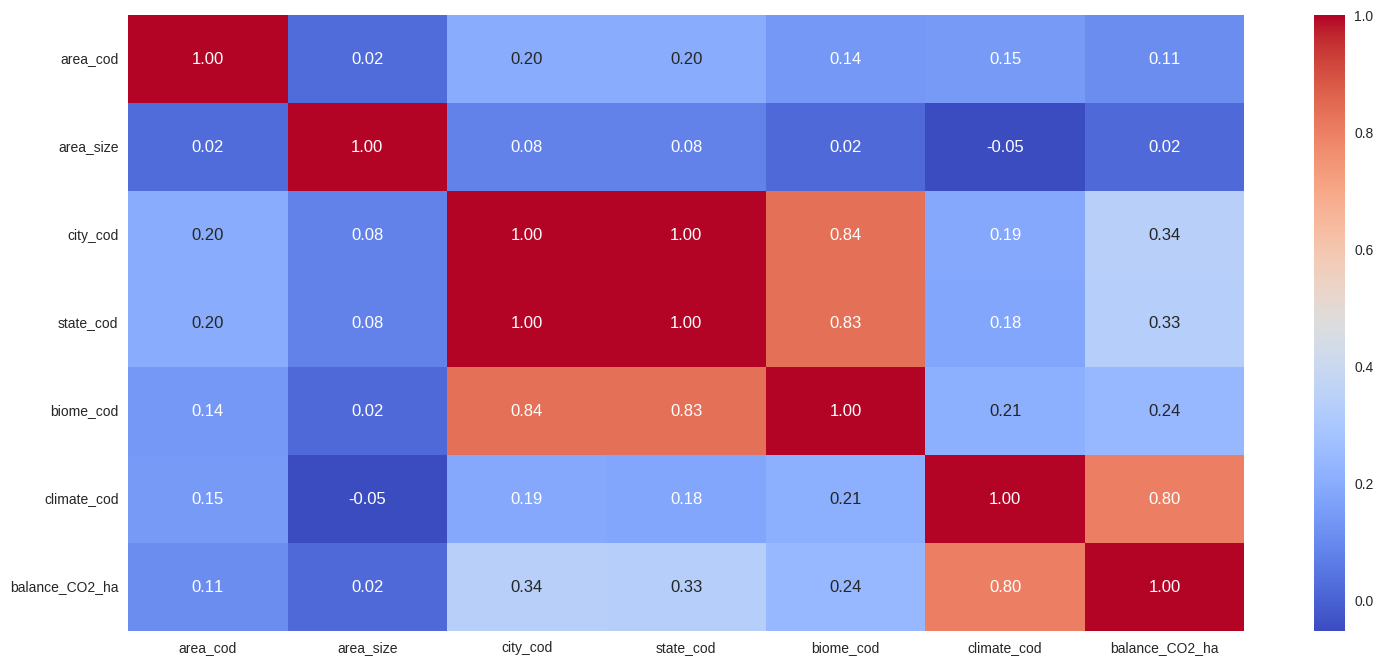

In [4]:

# 🚀 SETUP GLOBAL PARA xAI E PREVENÇÃO DE VAZAMENTO DE DADOS
features_xai = [
    'area_cod',     # Uso do Solo
    'area_size',    # Tamanho da Área
    'city_cod',     # Cidade
    'state_cod',    # Estado
    'biome_cod',    # Bioma
    'climate_cod'   # Clima
]
target = 'balance_CO2_ha'

# Correlation APENAS com as features permitidas e o target (Sem Data Leakage)
colunas_correlacao = features_xai + [target]
all_areas_df_corr = all_areas_df[colunas_correlacao]

figura = plt.figure(figsize=(18,8))
sns.heatmap(all_areas_df_corr.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

In [5]:
all_areas_df.count()

,0
index,22800
farm,22800
area_cod,22800
area_name,22800
area_size,22800
CO2_emission_area,22800
CO2_emission_ha,22800
CO2_stock_area,22800
CO2_stock_ha,22800
balance_CO2_area,22800


#**Linear Regression - Simple**

In [ ]:
# X is the single predictor attribute: climate_cod
X_areas = all_areas_df['climate_cod'].values
X_areas

array([2, 2, 2, ..., 3, 3, 3])

In [7]:
# Y is the attribute: balance_CO2_ha
Y_areas = all_areas_df[target].values
Y_areas

array([31.34932631, 23.9499024 , 21.89796901, ..., 28.30590842,
       22.06088245, 19.40320279])

In [8]:
X_areas.shape, Y_areas.shape

((22800,), (22800,))

In [9]:
# Correlation coefficient
np.corrcoef(X_areas, Y_areas)

array([[1.        , 0.80127047],
       [0.80127047, 1.        ]])

In [10]:
# Transforming array into matrix (required for sklearn)
X_areas = X_areas.reshape(-1,1)
X_areas

array([[2],
       [2],
       [2],
       ...,
       [3],
       [3],
       [3]])

In [11]:
X_areas.shape

(22800, 1)

**Standardization, if necessary**

In [ ]:
# This prevents scaling bias and ensures stable training for neural networks and polynomial models.
scaler_areas_x = StandardScaler()
X_areas = scaler_areas_x.fit_transform((X_areas).reshape(-1,1))
scaler_areas_y = StandardScaler()
Y_areas = scaler_areas_y.fit_transform((Y_areas).reshape(-1,1))
X_areas, Y_areas

(array([[-1.27582858],
        [-1.27582858],
        [-1.27582858],
        ...,
        [-0.80008457],
        [-0.80008457],
        [-0.80008457]]),
 array([[-0.46585766],
        [-1.24586181],
        [-1.46216467],
        ...,
        [-0.78667704],
        [-1.44499128],
        [-1.72514839]]))

**Using the entire database**

In [13]:
# Create the regression model (for all data)
simple_linear_regressor = LinearRegression()
simple_linear_regressor.fit(X_areas, Y_areas)

LinearRegression()

In [14]:
# b0 : beginning of the regression line and b1: slope of the line
simple_linear_regressor.intercept_, simple_linear_regressor.coef_

(array([2.9502217e-16]), array([[0.80127047]]))

In [15]:
# Prevision
prevision_simple_linear_regressor = simple_linear_regressor.predict(X_areas)
prevision_simple_linear_regressor

array([[-1.02228376],
       [-1.02228376],
       [-1.02228376],
       ...,
       [-0.64108414],
       [-0.64108414],
       [-0.64108414]])

In [16]:
# Convert matrix to array (for the graph)
X_areas.ravel()

array([-1.27582858, -1.27582858, -1.27582858, ..., -0.80008457,
       -0.80008457, -0.80008457])

In [ ]:
# Prediction with a standardized climate code (value 15) = estimated value of carbon/ha
simple_linear_regressor.intercept_ + scaler_areas_x.transform([[15]])[0][0]

array([[12.01905702]])

In [ ]:
# Scale the raw value before passing it to the predict function
raw_value = [[15]]
scaled_value = scaler_areas_x.transform(raw_value)

simple_linear_regressor.predict(scaled_value)

array([[12.01905702]])

In [19]:
# score: algorithm quality metric (closest to 1 best value)
simple_linear_regressor.score(X_areas, Y_areas)

0.6420343627481244

In [20]:
# Mean absolute error
mean_absolute_error(Y_areas, prevision_simple_linear_regressor)

0.4671374914568191

In [21]:
# Mean squared error
mean_squared_error(Y_areas, prevision_simple_linear_regressor)

0.3579656372518755

In [22]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas, prevision_simple_linear_regressor))

np.float64(0.5983022958771557)

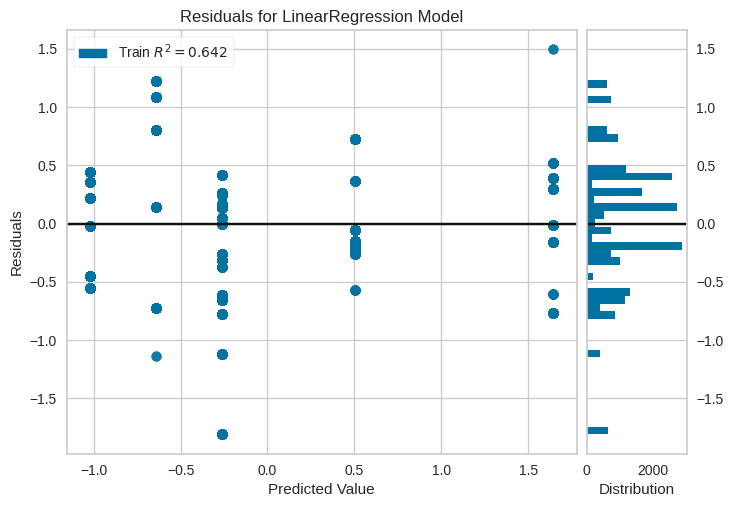

<Axes: title={'center': 'Residuals for LinearRegression Model'}, xlabel='Predicted Value', ylabel='Residuals'>

In [23]:
# distance from the original values to the linear regression line (Train R2 = algorithm quality)
viewer = ResidualsPlot(simple_linear_regressor)
viewer.fit(X_areas, Y_areas)
viewer.poof()

<Axes: >

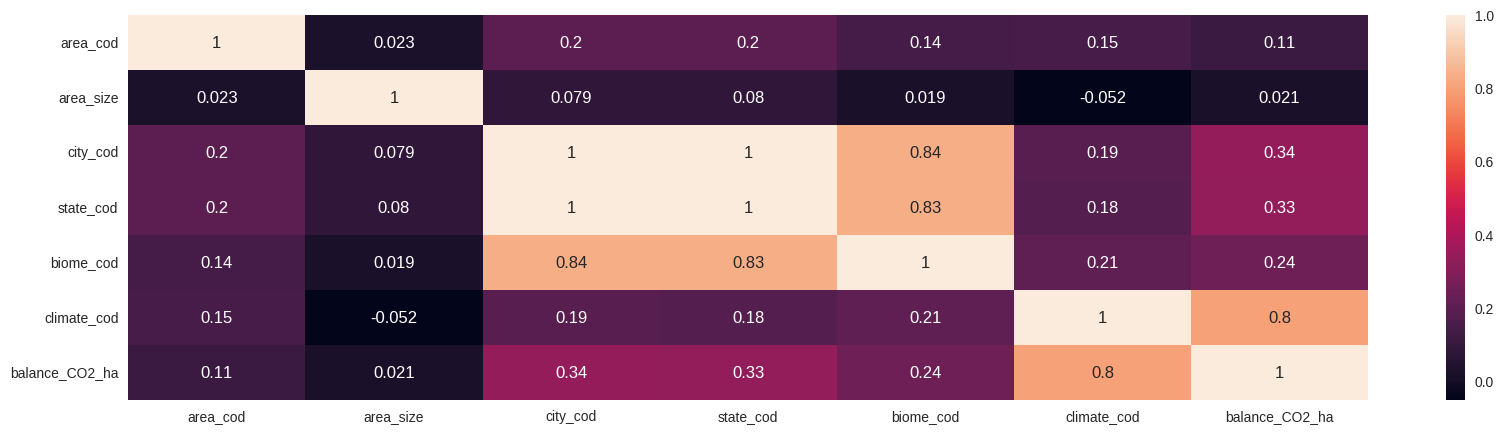

In [24]:
# Correlation viewer
figure = plt.figure(figsize=(20,5))
sns.heatmap(all_areas_df_corr.corr(), annot=True)

**Simple Linear Regression - training and testing bases**

In [25]:
# Division of bases (75% trein, 25% test)
X_areas_trein, X_areas_test, Y_areas_trein, Y_areas_test = train_test_split(X_areas, Y_areas, test_size = 0.25, random_state = 0)

In [26]:
X_areas_trein.shape, Y_areas_trein.shape, X_areas_test.shape, Y_areas_test.shape

((17100, 1), (17100, 1), (5700, 1), (5700, 1))


**Standardization, if necessary**

In [ ]:
# We fit and transform the training set, but only transform the test set 
# using the exact parameters (mean and variance) learned from the training data.
scaler_areas_x = StandardScaler()
X_areas_trein = scaler_areas_x.fit_transform((X_areas_trein).reshape(-1,1))
X_areas_test = scaler_areas_x.transform((X_areas_test).reshape(-1,1))

scaler_areas_y = StandardScaler()
Y_areas_trein = scaler_areas_y.fit_transform((Y_areas_trein).reshape(-1,1))
Y_areas_test = scaler_areas_y.transform((Y_areas_test).reshape(-1,1))

X_areas_trein, Y_areas_trein, X_areas_test, Y_areas_test


(array([[ 2.04293687],
        [ 2.04293687],
        [-0.33024732],
        ...,
        [-0.33024732],
        [-0.33024732],
        [ 2.04293687]]),
 array([[ 1.33939139],
        [ 1.33939139],
        [-0.43073256],
        ...,
        [-0.68259947],
        [-0.68259947],
        [ 1.33939139]]),
 array([[ 0.65193813],
        [ 2.08966603],
        [-0.30654713],
        ...,
        [ 2.08966603],
        [-0.30654713],
        [-0.78578976]]),
 array([[ 0.78860646],
        [ 1.3769533 ],
        [ 0.01619678],
        ...,
        [ 1.28449882],
        [-0.40969116],
        [-1.43640598]]))

**Regression Model for training**

In [28]:
# Convert array to matrix
X_areas_trein = X_areas_trein.reshape(-1,1)
X_areas_trein

array([[ 2.04293687],
       [ 2.04293687],
       [-0.33024732],
       ...,
       [-0.33024732],
       [-0.33024732],
       [ 2.04293687]])

In [29]:
# Create the regression model (trein)
simple_linear_regressor_trein = LinearRegression()
simple_linear_regressor_trein.fit(X_areas_trein, Y_areas_trein)

LinearRegression()

In [30]:
# score: algorithm quality metric (trein)
simple_linear_regressor_trein.score(X_areas_trein, Y_areas_trein)

0.6402051597659755

In [31]:
# Prevision (trein)
prevision_simple_linear_regressor_trein = simple_linear_regressor_trein.predict(X_areas_trein)
prevision_simple_linear_regressor_trein

array([[ 1.63461143],
       [ 1.63461143],
       [-0.26424019],
       ...,
       [-0.26424019],
       [-0.26424019],
       [ 1.63461143]])

In [32]:
# Real data
Y_areas_trein

array([[ 1.33939139],
       [ 1.33939139],
       [-0.43073256],
       ...,
       [-0.68259947],
       [-0.68259947],
       [ 1.33939139]])

In [33]:
# Mean absolute error
abs(Y_areas_trein-prevision_simple_linear_regressor_trein).mean()

np.float64(0.4676665495531181)

In [34]:
# Mean absolute error
mean_absolute_error(Y_areas_trein, prevision_simple_linear_regressor_trein)

0.4676665495531181

In [35]:
# Mean squared error
mean_squared_error(Y_areas_trein, prevision_simple_linear_regressor_trein)

0.3597948402340246

In [36]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_trein, prevision_simple_linear_regressor_trein))

np.float64(0.5998290091634654)

In [ ]:
# Prediction with a standardized climate code (value 15) = estimated value of carbon/ha
simple_linear_regressor_trein.intercept_ + scaler_areas_x.transform([[15]])[0][0]

array([[12.00192322]])

**Regression Model for testing**

In [38]:
# Convert array to matrix
X_areas_test = X_areas_test.reshape(-1,1)
X_areas_test

array([[ 0.65193813],
       [ 2.08966603],
       [-0.30654713],
       ...,
       [ 2.08966603],
       [-0.30654713],
       [-0.78578976]])

In [39]:
# Create the regression model (test)
simple_linear_regressor_test = LinearRegression()
simple_linear_regressor_test.fit(X_areas_test, Y_areas_test)

LinearRegression()

In [40]:
# score: algorithm quality metric (test)
simple_linear_regressor_test.score(X_areas_test, Y_areas_test)

0.6474830714261044

In [41]:
# Prevision (test)
prevision_simple_linear_regressor_test = simple_linear_regressor_test.predict(X_areas_test)
prevision_simple_linear_regressor_test

array([[ 0.52459071],
       [ 1.68147762],
       [-0.24666723],
       ...,
       [ 1.68147762],
       [-0.24666723],
       [-0.6322962 ]])

In [42]:
# Real data
Y_areas_test

array([[ 0.78860646],
       [ 1.3769533 ],
       [ 0.01619678],
       ...,
       [ 1.28449882],
       [-0.40969116],
       [-1.43640598]])

In [43]:
# Mean absolute error
abs(Y_areas_test-prevision_simple_linear_regressor_test).mean()

np.float64(0.4656144869597011)

In [44]:
# Mean absolute error
mean_absolute_error(Y_areas_test, prevision_simple_linear_regressor_test)

0.4656144869597011

In [45]:
# Mean squared error
mean_squared_error(Y_areas_test, prevision_simple_linear_regressor_test)

0.35251692857389566

In [46]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_test, prevision_simple_linear_regressor_test))

np.float64(0.5937313606117632)

In [ ]:
# Prediction with a value  (area 15) = estimated value of carbon/ha
simple_linear_regressor_trein.intercept_ + scaler_areas_x.transform([[15]])[0][0]

array([[12.00192322]])

# **Linear Regression - Multiple**

In [ ]:
# X matrix composed of the 6 multi-criteria features (area code, Size, City, State, Biome, Climate)
X_areas_mult = all_areas_df[features_xai].values
X_areas_mult

array([[3.000000e+00, 5.350000e+00, 1.100908e+06, 1.100000e+01,
        1.000000e+00, 2.000000e+00],
       [1.200000e+01, 2.700000e-01, 1.100908e+06, 1.100000e+01,
        1.000000e+00, 2.000000e+00],
       [1.500000e+01, 6.979000e+01, 1.100908e+06, 1.100000e+01,
        1.000000e+00, 2.000000e+00],
       ...,
       [4.000000e+00, 8.295000e+01, 2.312908e+06, 2.300000e+01,
        2.000000e+00, 3.000000e+00],
       [1.200000e+01, 6.800000e-01, 2.312908e+06, 2.300000e+01,
        2.000000e+00, 3.000000e+00],
       [1.500000e+01, 2.960000e+00, 2.312908e+06, 2.300000e+01,
        2.000000e+00, 3.000000e+00]])

In [49]:
# # Y is the attribute: balance_CO2_ha
Y_areas_mult = all_areas_df[target].values
Y_areas_mult

array([31.34932631, 23.9499024 , 21.89796901, ..., 28.30590842,
       22.06088245, 19.40320279])

**Using the entire database**

**Standardization, if necessary**

In [50]:
scaler_areas_x = StandardScaler()
X_areas_mult = scaler_areas_x.fit_transform((X_areas_mult))
scaler_areas_y = StandardScaler()
Y_areas_mult = scaler_areas_y.fit_transform((Y_areas_mult).reshape(-1,1))
X_areas_mult, Y_areas_mult

(array([[-1.04928986, -0.15360278, -1.91303817, -1.9020608 , -1.56937648,
         -1.27582858],
        [-0.31583817, -0.1726386 , -1.91303817, -1.9020608 , -1.56937648,
         -1.27582858],
        [-0.07135427,  0.08786743, -1.91303817, -1.9020608 , -1.56937648,
         -1.27582858],
        ...,
        [-0.96779522,  0.13718072, -1.05597807, -1.05403348, -1.00591931,
         -0.80008457],
        [-0.31583817, -0.17110225, -1.05597807, -1.05403348, -1.00591931,
         -0.80008457],
        [-0.07135427, -0.16255861, -1.05597807, -1.05403348, -1.00591931,
         -0.80008457]]),
 array([[-0.46585766],
        [-1.24586181],
        [-1.46216467],
        ...,
        [-0.78667704],
        [-1.44499128],
        [-1.72514839]]))

In [51]:
# Create the regression model (for all data)
mult_linear_regressor = LinearRegression()
mult_linear_regressor.fit(X_areas_mult, Y_areas_mult)

LinearRegression()

In [52]:
# Prevision
prevision_mult_linear_regressor = mult_linear_regressor.predict(X_areas_mult)
prevision_mult_linear_regressor

array([[-1.00043807],
       [-1.05776454],
       [-1.06859602],
       ...,
       [-1.12598412],
       [-1.18597861],
       [-1.2046256 ]])

In [53]:
# score: algorithm quality metric (closest to 1 best value)
mult_linear_regressor.score(X_areas_mult, Y_areas_mult)

0.7443296200204027

In [54]:
# Mean absolute error
mean_absolute_error(Y_areas_mult, prevision_mult_linear_regressor)

0.40270517705959974

In [55]:
# Mean squared error
mean_squared_error(Y_areas_mult, prevision_mult_linear_regressor)

0.2556703799795973

In [56]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_mult, prevision_mult_linear_regressor))

np.float64(0.5056385863238656)

**Multiple Linear Regression - training and testing bases**

In [57]:
# Division of bases (75% trein, 25% test)
X_areas_mult_trein, X_areas_mult_test, Y_areas_mult_trein, Y_areas_mult_test = train_test_split(X_areas_mult, Y_areas_mult, test_size = 0.25, random_state = 0)

In [58]:
X_areas_mult_trein.shape, Y_areas_mult_trein.shape, X_areas_mult_test.shape, Y_areas_mult_test.shape

((17100, 6), (17100, 1), (5700, 6), (5700, 1))

**Standardization, if necessary**


In [ ]:
scaler_areas_x_mult = StandardScaler()
X_areas_mult_trein = scaler_areas_x_mult.fit_transform((X_areas_mult_trein))
X_areas_mult_test = scaler_areas_x_mult.fit_transform((X_areas_mult_test))

scaler_areas_y_mult = StandardScaler()
Y_areas_mult_trein = scaler_areas_y_mult.transform((Y_areas_mult_trein))
Y_areas_mult_test = scaler_areas_y_mult.transform((Y_areas_mult_test))

X_areas_mult_trein, Y_areas_mult_trein, X_areas_mult_test, Y_areas_mult_test

(array([[ 0.41451135, -0.15136168, -0.47463678, -0.49368236, -0.44503961,
          2.04293687],
        [ 0.41451135, -0.16520356, -0.47463678, -0.49368236, -0.44503961,
          2.04293687],
        [ 0.41451135,  1.90797261,  0.92012512,  0.92456378,  1.25012909,
         -0.33024732],
        ...,
        [-0.07364724,  5.29032881,  0.92012512,  0.92456378,  1.25012909,
         -0.33024732],
        [-0.07364724, -0.13627713,  0.92012512,  0.92456378,  1.25012909,
         -0.33024732],
        [ 0.41451135, -0.08802038, -0.47463678, -0.49368236, -0.44503961,
          2.04293687]]),
 array([[ 1.33939139],
        [ 1.33939139],
        [-0.43073256],
        ...,
        [-0.68259947],
        [-0.68259947],
        [ 1.33939139]]),
 array([[ 2.06512812, -0.2232993 ,  0.36946258,  0.36554954,  0.68265028,
          0.65193813],
        [ 0.42700428, -0.2233543 , -0.45481924, -0.4739478 , -0.43484156,
          2.08966603],
        [-0.96540098, -0.2072379 ,  0.92096828,  0.92521

**Regression Model for training**

In [60]:
# Create the regression model (trein)
mult_linear_regressor_trein = LinearRegression()
mult_linear_regressor_trein.fit(X_areas_mult_trein, Y_areas_mult_trein)

LinearRegression()

In [61]:
# score: algorithm quality metric (trein)
mult_linear_regressor_trein.score(X_areas_mult_trein, Y_areas_mult_trein)

0.7440919786026765

In [62]:
# Prevision (trein)
prevision_mult_linear_regressor_trein = mult_linear_regressor_trein.predict(X_areas_mult_trein)
prevision_mult_linear_regressor_trein

array([[ 1.47308489],
       [ 1.47263003],
       [-0.20198712],
       ...,
       [-0.05431278],
       [-0.232637  ],
       [ 1.47516636]])

In [63]:
# Real data
Y_areas_mult_trein

array([[ 1.33939139],
       [ 1.33939139],
       [-0.43073256],
       ...,
       [-0.68259947],
       [-0.68259947],
       [ 1.33939139]])

In [64]:
# Mean absolute error
mean_absolute_error(Y_areas_mult_trein, prevision_mult_linear_regressor_trein)

0.4028501886214995

In [65]:
# Mean squared error
mean_squared_error(Y_areas_mult_trein, prevision_mult_linear_regressor_trein)

0.25590802139732355

In [66]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_mult_trein, prevision_mult_linear_regressor_trein))

np.float64(0.5058735231234419)

**Regression Model for testing**

In [67]:
# Create the regression model (test)
mult_linear_regressor_test = LinearRegression()
mult_linear_regressor_test.fit(X_areas_mult_test, Y_areas_mult_test)

LinearRegression()

In [68]:
# score: algorithm quality metric (test)
mult_linear_regressor_test.score(X_areas_mult_test, Y_areas_mult_test)

0.7454154489957963

In [69]:
# Prevision (test)
prevision_mult_linear_regressor_test = mult_linear_regressor_test.predict(X_areas_mult_test)
prevision_mult_linear_regressor_test

array([[ 0.4173611 ],
       [ 1.49870767],
       [ 0.40921168],
       ...,
       [ 1.54066069],
       [-0.22698893],
       [-1.17120787]])

In [70]:
# Real data
Y_areas_mult_test

array([[ 0.78860646],
       [ 1.3769533 ],
       [ 0.01619678],
       ...,
       [ 1.28449882],
       [-0.40969116],
       [-1.43640598]])

In [71]:
# Mean absolute error
mean_absolute_error(Y_areas_mult_test, prevision_mult_linear_regressor_test)

0.4016945528539831

In [72]:
# Mean squared error
mean_squared_error(Y_areas_mult_test, prevision_mult_linear_regressor_test)

0.2545845510042037

In [73]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_mult_test, prevision_mult_linear_regressor_test))

np.float64(0.5045637234326341)

# **Polynomial Regression**

In [ ]:
# X is the single predictor feature: climate_cod
X_areas = all_areas_df['climate_cod'].values
X_areas

array([2, 2, 2, ..., 3, 3, 3])

In [75]:
# Y is the attribute: balance_CO2_ha
Y_areas = all_areas_df[target].values
Y_areas

array([31.34932631, 23.9499024 , 21.89796901, ..., 28.30590842,
       22.06088245, 19.40320279])

In [76]:
scaler_polynomial_x = StandardScaler()
X_areas  = scaler_polynomial_x.fit_transform(X_areas.reshape(-1,1))
X_areas

array([[-1.27582858],
       [-1.27582858],
       [-1.27582858],
       ...,
       [-0.80008457],
       [-0.80008457],
       [-0.80008457]])

In [77]:
scaler_polynomial_y = StandardScaler()
Y_areas  = scaler_polynomial_y.fit_transform(Y_areas.reshape(-1,1))
Y_areas

array([[-0.46585766],
       [-1.24586181],
       [-1.46216467],
       ...,
       [-0.78667704],
       [-1.44499128],
       [-1.72514839]])

In [78]:
# Apply degree to the polynomial
polynomial_degree = PolynomialFeatures(degree=8)

**Using the entire database**

In [79]:
# Transforming array into matrix (required for sklearn)
X_areas = X_areas.reshape(-1,1)
X_areas

array([[-1.27582858],
       [-1.27582858],
       [-1.27582858],
       ...,
       [-0.80008457],
       [-0.80008457],
       [-0.80008457]])

In [80]:
# Apply polynominal degree in X
X_areas_poly = polynomial_degree.fit_transform(X_areas)

In [81]:
X_areas_poly.shape

(22800, 9)

In [82]:
X_areas_poly

array([[ 1.        , -1.27582858,  1.62773856, ...,  4.31274677,
        -5.50232558,  7.02002423],
       [ 1.        , -1.27582858,  1.62773856, ...,  4.31274677,
        -5.50232558,  7.02002423],
       [ 1.        , -1.27582858,  1.62773856, ...,  4.31274677,
        -5.50232558,  7.02002423],
       ...,
       [ 1.        , -0.80008457,  0.64013532, ...,  0.26231032,
        -0.20987044,  0.1679141 ],
       [ 1.        , -0.80008457,  0.64013532, ...,  0.26231032,
        -0.20987044,  0.1679141 ],
       [ 1.        , -0.80008457,  0.64013532, ...,  0.26231032,
        -0.20987044,  0.1679141 ]])

In [83]:
# Create the regression model (for all data)
poly_simple_linear_regressor = LinearRegression()
poly_simple_linear_regressor.fit(X_areas_poly, Y_areas)

LinearRegression()

In [84]:
# Score: algorithm quality metric (closest to 1 best value)
poly_simple_linear_regressor.score(X_areas_poly, Y_areas)

0.7165754415363537

In [85]:
# Prevision
prevision_poly_simple_linear_regressor = poly_simple_linear_regressor.predict(X_areas_poly)
prevision_poly_simple_linear_regressor

array([[-1.032336  ],
       [-1.032336  ],
       [-1.032336  ],
       ...,
       [-1.19611949],
       [-1.19611949],
       [-1.19611949]])

In [86]:
# Real data
Y_areas

array([[-0.46585766],
       [-1.24586181],
       [-1.46216467],
       ...,
       [-0.78667704],
       [-1.44499128],
       [-1.72514839]])

In [87]:
# Mean absolute error
mean_absolute_error(Y_areas, prevision_poly_simple_linear_regressor)

0.4399946687126049

In [88]:
# Mean squared error
mean_squared_error(Y_areas, prevision_poly_simple_linear_regressor)

0.2834245584636463

In [89]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas, prevision_poly_simple_linear_regressor))

np.float64(0.5323763316148139)

In [90]:
# Prevision
new_value = [[15]]
new_value = polynomial_degree.transform(new_value)
new_value

array([[1.00000000e+00, 1.50000000e+01, 2.25000000e+02, 3.37500000e+03,
        5.06250000e+04, 7.59375000e+05, 1.13906250e+07, 1.70859375e+08,
        2.56289062e+09]])

In [91]:
poly_simple_linear_regressor.predict(new_value)

array([[5.26551486e+08]])

**Polynomial Linear Regression - training and testing bases**

In [92]:
# Division of bases (75% trein, 25% test)
X_areas_trein, X_areas_test, Y_areas_trein, Y_areas_test = train_test_split(X_areas, Y_areas, test_size = 0.25, random_state = 0)

**Regression Model for training**

In [93]:
X_areas_trein.shape, Y_areas_trein.shape

((17100, 1), (17100, 1))

In [94]:
# Transforming array into matrix (required for sklearn)
X_areas_trein = X_areas_trein.reshape(-1,1)
X_areas_trein

array([[ 2.05437947],
       [ 2.05437947],
       [-0.32434056],
       ...,
       [-0.32434056],
       [-0.32434056],
       [ 2.05437947]])

In [95]:
# Apply polynominal degree in X
X_areas_trein_poly = polynomial_degree.fit_transform(X_areas_trein)
X_areas_trein_poly.shape

(17100, 9)

In [96]:
# Create the regression model
poly_simple_linear_regressor_trein = LinearRegression()
poly_simple_linear_regressor_trein.fit(X_areas_trein_poly, Y_areas_trein)

LinearRegression()

In [97]:
# Score: algorithm quality metric (closest to 1 best value)
poly_simple_linear_regressor_trein.score(X_areas_trein_poly, Y_areas_trein)

0.7151488649131478

In [98]:
# Prevision
prevision_poly_simple_linear_regressor_trein = poly_simple_linear_regressor_trein.predict(X_areas_trein_poly)
prevision_poly_simple_linear_regressor_trein

array([[ 1.55322842],
       [ 1.55322842],
       [-0.0037246 ],
       ...,
       [-0.0037246 ],
       [-0.0037246 ],
       [ 1.55322842]])

In [99]:
# Real data
Y_areas_trein

array([[ 1.34862742],
       [ 1.34862742],
       [-0.42548064],
       ...,
       [-0.67791444],
       [-0.67791444],
       [ 1.34862742]])

In [100]:
# Mean absolute error
mean_absolute_error(Y_areas_trein, prevision_poly_simple_linear_regressor_trein)

0.4420434273563239

In [101]:
# Mean squared error
mean_squared_error(Y_areas_trein, prevision_poly_simple_linear_regressor_trein)

0.28613484008819184

In [102]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_trein, prevision_poly_simple_linear_regressor_trein))

np.float64(0.5349157317636039)

**Regression Model for testing**

In [103]:
X_areas_test.shape, Y_areas_test.shape

((5700, 1), (5700, 1))

In [104]:
# Transforming array into matrix (required for sklearn)
X_areas_test = X_areas_test.reshape(-1,1)
X_areas_test

array([[ 0.62714745],
       [ 2.05437947],
       [-0.32434056],
       ...,
       [ 2.05437947],
       [-0.32434056],
       [-0.80008457]])

In [105]:
# Apply polynominal degree in X
X_areas_test_poly = polynomial_degree.fit_transform(X_areas_test)
X_areas_test_poly.shape

(5700, 9)

In [106]:
# Create the regression model
poly_simple_linear_regressor_test = LinearRegression()
poly_simple_linear_regressor_test.fit(X_areas_test_poly, Y_areas_test)

LinearRegression()

In [107]:
# Score: algorithm quality metric (closest to 1 best value)
poly_simple_linear_regressor_test.score(X_areas_test_poly, Y_areas_test)

0.7209327435180226

In [108]:
# Prevision
prevision_poly_simple_linear_regressor_test = poly_simple_linear_regressor_test.predict(X_areas_test_poly)
prevision_poly_simple_linear_regressor_test

array([[ 0.4659656 ],
       [ 1.54330301],
       [-0.01153764],
       ...,
       [ 1.54330301],
       [-0.01153764],
       [-1.18935491]])

In [109]:
# Real data
Y_areas_test

array([[ 0.76440886],
       [ 1.34862742],
       [-0.00258105],
       ...,
       [ 1.25682168],
       [-0.42548064],
       [-1.44499128]])

In [110]:
# Mean absolute error
mean_absolute_error(Y_areas_test, prevision_poly_simple_linear_regressor_test)

0.43366517124053866

In [111]:
# Mean squared error
mean_squared_error(Y_areas_test, prevision_poly_simple_linear_regressor_test)

0.2751647201075029

In [112]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_test, prevision_poly_simple_linear_regressor_test))

np.float64(0.5245614550341103)

# **Polynomial Regression - Multiple**

In [113]:
# X composed of attributes: area_cod, city_cod, climate_cod
X_areas_mult = all_areas_df[features_xai].values
X_areas_mult

array([[3.000000e+00, 5.350000e+00, 1.100908e+06, 1.100000e+01,
        1.000000e+00, 2.000000e+00],
       [1.200000e+01, 2.700000e-01, 1.100908e+06, 1.100000e+01,
        1.000000e+00, 2.000000e+00],
       [1.500000e+01, 6.979000e+01, 1.100908e+06, 1.100000e+01,
        1.000000e+00, 2.000000e+00],
       ...,
       [4.000000e+00, 8.295000e+01, 2.312908e+06, 2.300000e+01,
        2.000000e+00, 3.000000e+00],
       [1.200000e+01, 6.800000e-01, 2.312908e+06, 2.300000e+01,
        2.000000e+00, 3.000000e+00],
       [1.500000e+01, 2.960000e+00, 2.312908e+06, 2.300000e+01,
        2.000000e+00, 3.000000e+00]])

In [114]:
# Y is the attribute: balance_CO2_ha
Y_areas_mult = all_areas_df[target].values
Y_areas_mult

array([31.34932631, 23.9499024 , 21.89796901, ..., 28.30590842,
       22.06088245, 19.40320279])

**Standardization, in this algorithm is very important**

In [115]:
scaler_mult_polynomial_x = StandardScaler()
X_areas_mult  = scaler_mult_polynomial_x.fit_transform(X_areas_mult)
X_areas_mult

array([[-1.04928986, -0.15360278, -1.91303817, -1.9020608 , -1.56937648,
        -1.27582858],
       [-0.31583817, -0.1726386 , -1.91303817, -1.9020608 , -1.56937648,
        -1.27582858],
       [-0.07135427,  0.08786743, -1.91303817, -1.9020608 , -1.56937648,
        -1.27582858],
       ...,
       [-0.96779522,  0.13718072, -1.05597807, -1.05403348, -1.00591931,
        -0.80008457],
       [-0.31583817, -0.17110225, -1.05597807, -1.05403348, -1.00591931,
        -0.80008457],
       [-0.07135427, -0.16255861, -1.05597807, -1.05403348, -1.00591931,
        -0.80008457]])

In [116]:
scaler_mult_polynomial_y = StandardScaler()
Y_areas_mult = scaler_mult_polynomial_y.fit_transform(Y_areas_mult.reshape(-1, 1))
Y_areas_mult

array([[-0.46585766],
       [-1.24586181],
       [-1.46216467],
       ...,
       [-0.78667704],
       [-1.44499128],
       [-1.72514839]])

In [117]:
X_areas_mult.shape, Y_areas_mult.shape

((22800, 6), (22800, 1))

In [118]:
# Apply degree to the polynomial
mult_polynomial_degree = PolynomialFeatures(degree=5)

**Using the entire database**

In [119]:
# Apply polynominal degree in X
X_areas_mult_poly = mult_polynomial_degree.fit_transform(X_areas_mult)

In [120]:
X_areas_mult_poly.shape

(22800, 462)

In [121]:
# Create the regression model (for all data)
mult_poly_simple_linear_regressor = LinearRegression()
mult_poly_simple_linear_regressor.fit(X_areas_mult_poly, Y_areas_mult)

LinearRegression()

In [122]:
# Score: algorithm quality metric (closest to 1 best value)
mult_poly_simple_linear_regressor.score(X_areas_mult_poly, Y_areas_mult)

0.9804495353913989

In [123]:
# Prevision
prevision_mult_poly_simple_linear_regressor = mult_poly_simple_linear_regressor.predict(X_areas_mult_poly)
prevision_mult_poly_simple_linear_regressor

array([[-0.42512109],
       [-1.26378153],
       [-1.46168132],
       ...,
       [-0.69108344],
       [-1.52386206],
       [-1.72117856]])

In [124]:
# Real data
Y_areas_mult

array([[-0.46585766],
       [-1.24586181],
       [-1.46216467],
       ...,
       [-0.78667704],
       [-1.44499128],
       [-1.72514839]])

In [125]:
# Mean absolute error
mean_absolute_error(Y_areas_mult, prevision_mult_poly_simple_linear_regressor)

0.07928970698083686

In [126]:
# Mean squared error
mean_squared_error(Y_areas_mult, prevision_mult_poly_simple_linear_regressor)

0.019550464608601072

In [127]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_mult, prevision_mult_poly_simple_linear_regressor))

np.float64(0.13982297596819013)

**Cross Validation**

In [128]:
# Apply degree to the polynomial
mult_polynomial_degree = PolynomialFeatures(degree=15)

In [129]:
# Apply polynominal degree in X
X_areas_mult_poly = mult_polynomial_degree.fit_transform(X_areas_mult)

In [130]:
# Cross Validation Polynomial Regression (Multiple)
results_polynomial = []
for i in range(60):
  kfold = KFold(n_splits=10, shuffle=True, random_state=i)
  mult_polynomial_degree = PolynomialFeatures(degree=4)
  X_areas_mult_poly = mult_polynomial_degree.fit_transform(X_areas_mult)
  poly = LinearRegression()
  scores = cross_val_score(poly, X_areas_mult_poly, Y_areas_mult, cv=kfold)
  results_polynomial.append(scores.mean())

results_polynomial

[np.float64(-7.097908875092116),
 np.float64(-1.8461050210895351),
 np.float64(-1.8395273793557205),
 np.float64(-2.0502257501636394),
 np.float64(-2.312142472578933),
 np.float64(-2.196056709179847),
 np.float64(-2.006284381670158),
 np.float64(-2.1087170455320328),
 np.float64(-1.8678906730747407),
 np.float64(-2.065947392941026),
 np.float64(-22.702898069401076),
 np.float64(-12.811373179629019),
 np.float64(-3.082588088988771),
 np.float64(-1.9765934189100172),
 np.float64(-2.0918207869620273),
 np.float64(-1.897790827345979),
 np.float64(-1.4181196438953774),
 np.float64(-1.9383593776858237),
 np.float64(-2.245345391426932),
 np.float64(-2.3003237364013307),
 np.float64(-3.7663688297124542),
 np.float64(-2.117538617715512),
 np.float64(-2.0523958259295454),
 np.float64(-5.487691868363126),
 np.float64(-62.63776846871026),
 np.float64(-1.7917721700716054),
 np.float64(-1.729713854882159),
 np.float64(-2.108388040631959),
 np.float64(-2.611842863063911),
 np.float64(-1.9941578824814

**Multiple Linear Regression - training and testing bases**

In [131]:
# Division of bases (75% trein, 25% test)
X_areas_mult_trein, X_areas_mult_test, Y_areas_mult_trein, Y_areas_mult_test = train_test_split(X_areas_mult, Y_areas_mult, test_size = 0.25, random_state = 0)

In [132]:
X_areas_mult_trein.shape, Y_areas_mult_trein.shape, X_areas_mult_test.shape, Y_areas_mult_test.shape

((17100, 6), (17100, 1), (5700, 6), (5700, 1))

In [133]:
# Apply degree to the polynomial
mult_polynomial_degree = PolynomialFeatures(degree=15)

**Regression Model for training**

In [134]:
# Apply polynominal degree in X
X_areas_multi_poly_trein = mult_polynomial_degree.fit_transform(X_areas_mult_trein)

In [135]:
# Cross Validation Polynomial Regression (Multiple)
results_polynomial = []
for i in range(60):
  kfold = KFold(n_splits=10, shuffle=True, random_state=i)
  mult_polynomial_degree = PolynomialFeatures(degree=4)
  X_areas_multi_poly_trein = mult_polynomial_degree.fit_transform(X_areas_mult_trein)
  poly = LinearRegression()
  scores = cross_val_score(poly, X_areas_multi_poly_trein, Y_areas_mult_trein, cv=kfold)
  results_polynomial.append(scores.mean())

results_polynomial

[np.float64(-2.684569435219186),
 np.float64(-3.058573413032992),
 np.float64(-2.6467634715202166),
 np.float64(-2.8122300495794113),
 np.float64(-3.085018881253194),
 np.float64(-3.4977665488731824),
 np.float64(-2.2435424599319327),
 np.float64(-3.1538099557115933),
 np.float64(-2.5147954029110573),
 np.float64(-2.9811373746858485),
 np.float64(-2.397376910345939),
 np.float64(-3.0310090814111623),
 np.float64(-3.4152533811090073),
 np.float64(-2.4680059279201565),
 np.float64(-3.523459610822087),
 np.float64(-3.199284250280152),
 np.float64(-2.9907973948512323),
 np.float64(-3.1513209623956824),
 np.float64(-2.906531019818673),
 np.float64(-2.7052207799688666),
 np.float64(-3.222142524074507),
 np.float64(-2.5957892999513175),
 np.float64(-23.37016618245084),
 np.float64(-2.6355512601061957),
 np.float64(-4.02776155803767),
 np.float64(-2.48380409860708),
 np.float64(-2.88486659376618),
 np.float64(-3.2701261099326353),
 np.float64(-2.7134776572539128),
 np.float64(-3.54961039524316

In [136]:
# Create the regression model (for trein data)
poly_mult_linear_regressor = LinearRegression()
poly_mult_linear_regressor.fit(X_areas_multi_poly_trein, Y_areas_mult_trein)

LinearRegression()

In [137]:
# Score: algorithm quality metric (closest to 1 best value)
poly_mult_linear_regressor.score(X_areas_multi_poly_trein , Y_areas_mult_trein)

0.9602998688625893

In [138]:
# Prevision
prevision_poly_mult_linear_regressor_trein = poly_mult_linear_regressor.predict(X_areas_multi_poly_trein)
prevision_poly_mult_linear_regressor_trein

array([[ 1.25350965],
       [ 1.25984634],
       [-0.22213566],
       ...,
       [-0.80308666],
       [-0.68416573],
       [ 1.22810669]])

In [139]:
# Real data
Y_areas_mult_trein

array([[ 1.34862742],
       [ 1.34862742],
       [-0.42548064],
       ...,
       [-0.67791444],
       [-0.67791444],
       [ 1.34862742]])

In [140]:
# Mean absolute error
mean_absolute_error(Y_areas_mult_trein, prevision_poly_mult_linear_regressor_trein)

0.12532149347558869

In [141]:
# Mean squared error
mean_squared_error(Y_areas_mult_trein, prevision_poly_mult_linear_regressor_trein)

0.039879043034248954

In [142]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_mult_trein, prevision_poly_mult_linear_regressor_trein))

np.float64(0.1996973786363981)


**Regression Model for testing**

**Cross Validation**

In [143]:
# Apply degree to the polynomial
mult_polynomial_degree = PolynomialFeatures(degree=15)

In [144]:
# Apply polynominal degree in X
X_areas_multi_poly_test = mult_polynomial_degree.fit_transform(X_areas_mult_test)

In [145]:
# Cross Validation Polynomial Regression (Multiple)
results_polynomial = []
for i in range(60):
  kfold = KFold(n_splits=10, shuffle=True, random_state=i)
  mult_polynomial_degree = PolynomialFeatures(degree=4)
  X_areas_multi_poly_test = mult_polynomial_degree.fit_transform(X_areas_mult_test)
  poly = LinearRegression()
  scores = cross_val_score(poly, X_areas_multi_poly_test, Y_areas_mult_test, cv=kfold)
  results_polynomial.append(scores.mean())

results_polynomial

[np.float64(-1.6282828601596435),
 np.float64(-1.8345021685936793),
 np.float64(-2.1462849732974574),
 np.float64(-24.231184108557773),
 np.float64(-1.7083984362197164),
 np.float64(-1.6996239359067649),
 np.float64(-1.4895799460163497),
 np.float64(-1.2026715787388833),
 np.float64(-1.753398245906491),
 np.float64(-0.6270949499606543),
 np.float64(-0.933668065161978),
 np.float64(-1.3802158953796355),
 np.float64(-1.893153662125084),
 np.float64(-0.7697668501676058),
 np.float64(-1.3530054741481803),
 np.float64(-1.9834720820929874),
 np.float64(-1.299423005805606),
 np.float64(-0.36570197206967026),
 np.float64(-25.658944118908217),
 np.float64(-0.5557755672062716),
 np.float64(-1.1609679326546476),
 np.float64(-1.372418330900492),
 np.float64(-1.5664942138209808),
 np.float64(-1.9556301868874109),
 np.float64(-2.0752309780379035),
 np.float64(-0.35843939627249555),
 np.float64(-1.1867067958348119),
 np.float64(-2.2168875822929492),
 np.float64(-1.4017483719672446),
 np.float64(-16.0

In [146]:
# Create the regression model (for test data)
poly_mult_linear_regressor = LinearRegression()
poly_mult_linear_regressor.fit(X_areas_multi_poly_test, Y_areas_mult_test)

LinearRegression()

In [147]:
# Score: algorithm quality metric (closest to 1 best value)
poly_mult_linear_regressor.score(X_areas_multi_poly_test , Y_areas_mult_test)

0.9578113235031875

In [148]:
# Prevision
prevision_poly_mult_linear_regressor_test = poly_mult_linear_regressor.predict(X_areas_multi_poly_test)
prevision_poly_mult_linear_regressor_test

array([[-0.28140631],
       [ 1.23666327],
       [ 0.15134107],
       ...,
       [ 1.40803228],
       [-0.39721075],
       [-1.56716445]])

In [149]:
# Real Data
Y_areas_mult_test

array([[ 0.76440886],
       [ 1.34862742],
       [-0.00258105],
       ...,
       [ 1.25682168],
       [-0.42548064],
       [-1.44499128]])

In [150]:
# Mean absolute error
mean_absolute_error(Y_areas_mult_test, prevision_poly_mult_linear_regressor_test)

0.13020587964291525

In [151]:
# Mean squared error
mean_squared_error(Y_areas_mult_test, prevision_poly_mult_linear_regressor_test)

0.04159870099522444

In [152]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_mult_test, prevision_poly_mult_linear_regressor_test))

np.float64(0.20395759607140018)

# **Decision Tree Regression**

In [153]:
# X is the attribute: area_cod (predictor attribute) => (area_cod: 2, city_cod: 11, climate_cod: 17)
X_areas_tree = all_areas_df[['area_cod']].values
X_areas_tree

array([[ 3],
       [12],
       [15],
       ...,
       [ 4],
       [12],
       [15]])

In [154]:
# Y is the attribute: balance_CO2_ha
Y_areas_tree  = all_areas_df[target].values
Y_areas_tree

array([31.34932631, 23.9499024 , 21.89796901, ..., 28.30590842,
       22.06088245, 19.40320279])

**standardization**

In [155]:
scaler_areas_tree = StandardScaler()
X_areas_tree  = scaler_areas_tree.fit_transform(X_areas_tree)
X_areas_tree

array([[-1.04928986],
       [-0.31583817],
       [-0.07135427],
       ...,
       [-0.96779522],
       [-0.31583817],
       [-0.07135427]])

In [156]:
X_areas_tree.shape

(22800, 1)

**Using the entire database**

In [157]:
regressor_areas_tree = DecisionTreeRegressor()
regressor_areas_tree.fit(X_areas_tree, Y_areas_tree)

DecisionTreeRegressor()

In [158]:
# Prevision
prevision_areas_tree = regressor_areas_tree.predict(X_areas_tree)
prevision_areas_tree[:10]

array([40.62144703, 33.96084637, 29.83188697, 40.62144703, 33.96084637,
       29.83188697, 40.62144703, 29.83188697, 29.83188697, 29.83188697])

In [159]:
Y_areas_tree[:10]

array([31.34932631, 23.9499024 , 21.89796901, 31.34932631, 23.9499024 ,
       21.89796901, 31.34932631, 21.89796901, 21.89796901, 21.89796901])

In [160]:
# Score
regressor_areas_tree.score(X_areas_tree,Y_areas_tree)

0.2573133733910621

In [161]:
max_min_areas_tree = np.arange(np.min(X_areas_tree), np.max(X_areas_tree), 1)
max_min_areas_tree

array([-1.04928986, -0.04928986,  0.95071014,  1.95071014])

In [162]:
max_min_areas_tree.shape

(4,)

In [163]:
# Array to matrix
max_min_areas_tree = max_min_areas_tree.reshape(-1,1)
max_min_areas_tree.shape

(4, 1)

In [164]:
# Predict new value
regressor_areas_tree.predict([[9]])

array([57.14453484])

In [165]:
# Mean absolute error
mean_absolute_error(Y_areas_tree, prevision_areas_tree)

6.4562387037429225

In [166]:
# Mean squared error
mean_squared_error(Y_areas_tree, prevision_areas_tree)

66.83556022312499

In [167]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_tree, prevision_areas_tree))

np.float64(8.175301842936747)

**Decision Tree Regression - training and testing bases**

In [168]:
# Division of bases (75% trein, 25% test)
X_areas_tree_trein, X_areas_tree_test, Y_areas_tree_trein, Y_areas_tree_test = train_test_split(X_areas_tree, Y_areas_tree, test_size = 0.25, random_state = 0)
X_areas_tree_trein.shape, Y_areas_tree_trein.shape, X_areas_tree_test.shape, Y_areas_tree_test.shape

((17100, 1), (17100,), (5700, 1), (5700,))

**Decision Tree for training**

In [169]:
regressor_areas_tree = DecisionTreeRegressor()
regressor_areas_tree.fit(X_areas_tree_trein, Y_areas_tree_trein)

DecisionTreeRegressor()

In [170]:
# Prevision
prevision_areas_tree_trein = regressor_areas_tree.predict(X_areas_tree_trein)
prevision_areas_tree_trein[:10]

array([35.67371324, 35.67371324, 35.67371324, 34.03334075, 29.90336477,
       35.67371324, 35.67371324, 35.67371324, 40.64426883, 29.90336477])

In [171]:
Y_areas_tree_trein[:10]

array([48.5622402 , 48.5622402 , 31.73235842, 22.06088245, 21.89796901,
       31.73235842, 31.73235842, 31.73235842, 52.89525574, 21.89796901])

In [172]:
# Score
regressor_areas_tree.score(X_areas_tree_trein,Y_areas_tree_trein)

0.258375460165821

In [173]:
# Mean absolute error
mean_absolute_error(Y_areas_tree_trein, prevision_areas_tree_trein)

6.465009972315875

In [174]:
# Mean squared error
mean_squared_error(Y_areas_tree_trein, prevision_areas_tree_trein)

67.040750530816

In [175]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_tree_trein, prevision_areas_tree_trein))

np.float64(8.187841628342357)


**Decision Tree for testing**

In [176]:
regressor_areas_tree = DecisionTreeRegressor()
regressor_areas_tree.fit(X_areas_tree_test, Y_areas_tree_test)

DecisionTreeRegressor()

In [177]:
# Prevision
prevision_areas_tree_test = regressor_areas_tree.predict(X_areas_tree_test)
prevision_areas_tree_test[:10]

array([35.84904152, 35.68476771, 32.88754322, 33.7585858 , 32.88754322,
       40.1387862 , 35.84904152, 32.88754322, 35.68476771, 29.62056387])

In [178]:
Y_areas_tree_test[:10]

array([43.02011476, 48.5622402 , 35.74414912, 22.06088245, 35.74414912,
       50.47760445, 30.98005279, 35.74414912, 42.23133208, 30.81781452])

In [179]:
# Score
regressor_areas_tree.score(X_areas_tree_test,Y_areas_tree_test)

0.25412709173837056

In [180]:
# Mean absolute error
mean_absolute_error(Y_areas_tree_test, prevision_areas_tree_test)

6.427710014717395

In [181]:
# Mean squared error
mean_squared_error(Y_areas_tree_test, prevision_areas_tree_test)

66.18364619300837

In [182]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_tree_test, prevision_areas_tree_test))

np.float64(8.135333194959403)

# Decision Tree Regression - **Multiple**

In [183]:
# X composed of attributes: area_cod, city_cod, climate_cod (area_cod: 2, city_cod: 11, climate_cod: 17)
X_areas_tree_mult = all_areas_df[features_xai].values
X_areas_tree_mult

array([[3.000000e+00, 5.350000e+00, 1.100908e+06, 1.100000e+01,
        1.000000e+00, 2.000000e+00],
       [1.200000e+01, 2.700000e-01, 1.100908e+06, 1.100000e+01,
        1.000000e+00, 2.000000e+00],
       [1.500000e+01, 6.979000e+01, 1.100908e+06, 1.100000e+01,
        1.000000e+00, 2.000000e+00],
       ...,
       [4.000000e+00, 8.295000e+01, 2.312908e+06, 2.300000e+01,
        2.000000e+00, 3.000000e+00],
       [1.200000e+01, 6.800000e-01, 2.312908e+06, 2.300000e+01,
        2.000000e+00, 3.000000e+00],
       [1.500000e+01, 2.960000e+00, 2.312908e+06, 2.300000e+01,
        2.000000e+00, 3.000000e+00]])

In [184]:
# Y is the attribute: balance_CO2_ha
Y_areas_tree_mult  = all_areas_df[target].values.reshape(-1, 1)
Y_areas_tree_mult

array([[31.34932631],
       [23.9499024 ],
       [21.89796901],
       ...,
       [28.30590842],
       [22.06088245],
       [19.40320279]])

**Standardization:**
If you use it, you have to do the conversion in the prevision

In [185]:
scaler_areas_tree_mult = StandardScaler()
X_areas_tree_mult  = scaler_areas_tree_mult.fit_transform(X_areas_tree_mult)
X_areas_tree_mult

array([[-1.04928986, -0.15360278, -1.91303817, -1.9020608 , -1.56937648,
        -1.27582858],
       [-0.31583817, -0.1726386 , -1.91303817, -1.9020608 , -1.56937648,
        -1.27582858],
       [-0.07135427,  0.08786743, -1.91303817, -1.9020608 , -1.56937648,
        -1.27582858],
       ...,
       [-0.96779522,  0.13718072, -1.05597807, -1.05403348, -1.00591931,
        -0.80008457],
       [-0.31583817, -0.17110225, -1.05597807, -1.05403348, -1.00591931,
        -0.80008457],
       [-0.07135427, -0.16255861, -1.05597807, -1.05403348, -1.00591931,
        -0.80008457]])

In [186]:
X_areas_tree_mult.shape

(22800, 6)

In [187]:
regressor_areas_tree_mult = DecisionTreeRegressor()
regressor_areas_tree_mult.fit(X_areas_tree_mult, Y_areas_tree_mult)

DecisionTreeRegressor()

In [188]:
prevision_area_tree_mult = regressor_areas_tree_mult.predict(X_areas_tree_mult)
prevision_area_tree_mult[:10]

array([31.34932631, 23.9499024 , 21.89796901, 31.34932631, 23.9499024 ,
       21.89796901, 31.34932631, 21.89796901, 21.89796901, 21.89796901])

In [189]:
Y_areas_tree_mult[:10].ravel()

array([31.34932631, 23.9499024 , 21.89796901, 31.34932631, 23.9499024 ,
       21.89796901, 31.34932631, 21.89796901, 21.89796901, 21.89796901])

In [190]:
# Score
regressor_areas_tree_mult.score(X_areas_tree_mult,Y_areas_tree_mult)

1.0

In [191]:
# Mean absolute error
mean_absolute_error(Y_areas_tree_mult, prevision_area_tree_mult)

3.2994207755795637e-13

In [192]:
# Mean squared error
mean_squared_error(Y_areas_tree_mult, prevision_area_tree_mult)

1.7243642657508918e-25

In [193]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_tree_mult, prevision_area_tree_mult))

np.float64(4.152546526832531e-13)

In [194]:
# Predicting a value
regressor_areas_tree_mult.predict([[46, 150.0, 3161403, 31, 6, 8]])

array([57.14453484])

In [195]:
# Cross Validation Decision Tree Regression (Multiple)
results_tree = []
for i in range(120):
  kfold = KFold(n_splits=10, shuffle=True, random_state=i)
  tree = DecisionTreeRegressor()
  scores = cross_val_score(tree, X_areas_tree_mult, Y_areas_tree_mult, cv=kfold)
  results_tree.append(scores.mean())

results_tree

[np.float64(0.9999846461686281),
 np.float64(0.9997507696419206),
 np.float64(0.9999839030861273),
 np.float64(0.9997304259254403),
 np.float64(0.9999853181017215),
 np.float64(0.9999848730639188),
 np.float64(0.9999846163593503),
 np.float64(0.9999848248470069),
 np.float64(0.9999850312557583),
 np.float64(0.9999851946043098),
 np.float64(0.9997410909850576),
 np.float64(0.9999848439547012),
 np.float64(0.9999842270253264),
 np.float64(0.9999850951696116),
 np.float64(0.9994788052193198),
 np.float64(0.9999842262358154),
 np.float64(0.9999847668765096),
 np.float64(0.999984722098268),
 np.float64(0.9999848026329374),
 np.float64(0.9999843762862831),
 np.float64(0.99974850892193),
 np.float64(0.9999844590571891),
 np.float64(0.9999847897728597),
 np.float64(0.9999837610871891),
 np.float64(0.99998461852632),
 np.float64(0.9997450268991706),
 np.float64(0.9999841669207804),
 np.float64(0.9999847922446545),
 np.float64(0.9999847035396401),
 np.float64(0.9999844873464138),
 np.float64(0.9

**Multiple Decision Tree Regression - training and testing bases**

In [196]:
# # Division of bases (75% trein, 25% test)
X_areas_tree_mult_trein, X_areas_tree_mult_test, Y_areas_tree_mult_trein, Y_areas_tree_mult_test = train_test_split(X_areas_tree_mult, Y_areas_tree_mult, test_size = 0.25, random_state = 0)
X_areas_tree_mult_trein.shape, Y_areas_tree_mult_trein.shape, X_areas_tree_mult_test.shape, Y_areas_tree_mult_test.shape

((17100, 6), (17100, 1), (5700, 6), (5700, 1))

**Multiple Decision Tree for training**

In [197]:
regressor_areas_tree_mult_trein = DecisionTreeRegressor()
regressor_areas_tree_mult_trein.fit(X_areas_tree_mult_trein, Y_areas_tree_mult_trein)

DecisionTreeRegressor()

In [198]:
prevision_area_tree_mult_trein = regressor_areas_tree_mult_trein.predict(X_areas_tree_mult_trein)
prevision_area_tree_mult_trein[:10]

array([48.5622402 , 48.5622402 , 31.73235842, 22.06088245, 21.89796901,
       31.73235842, 31.73235842, 31.73235842, 52.89525574, 21.89796901])

In [199]:
Y_areas_tree_mult_trein[:10].ravel()

array([48.5622402 , 48.5622402 , 31.73235842, 22.06088245, 21.89796901,
       31.73235842, 31.73235842, 31.73235842, 52.89525574, 21.89796901])

In [200]:
# Score
regressor_areas_tree_mult_trein.score(X_areas_tree_mult_trein,Y_areas_tree_mult_trein)

1.0

In [201]:
# Predict a new value
regressor_areas_tree_mult_trein.predict([[46, 150.0, 3161403, 31, 6, 8]])

array([57.14453484])

In [202]:
53.49693611

53.49693611

In [203]:
# Mean absolute error
mean_absolute_error(Y_areas_tree_mult_trein, prevision_area_tree_mult_trein)

3.3644510179791517e-13

In [204]:
# Mean squared error
mean_squared_error(Y_areas_tree_mult_trein, prevision_area_tree_mult_trein)

1.7743227106253525e-25

In [205]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_tree_mult_trein, prevision_area_tree_mult_trein))

np.float64(4.2122710152901515e-13)

In [206]:
max_min_areas_tree = np.arange(np.min(X_areas_tree_mult_trein), np.max(X_areas_tree_mult_trein), 1)
max_min_areas_tree

array([-1.91303817, -0.91303817,  0.08696183,  1.08696183,  2.08696183,
        3.08696183,  4.08696183,  5.08696183,  6.08696183,  7.08696183,
        8.08696183,  9.08696183, 10.08696183, 11.08696183, 12.08696183,
       13.08696183, 14.08696183, 15.08696183, 16.08696183, 17.08696183,
       18.08696183, 19.08696183, 20.08696183, 21.08696183, 22.08696183,
       23.08696183, 24.08696183, 25.08696183, 26.08696183, 27.08696183,
       28.08696183, 29.08696183, 30.08696183, 31.08696183, 32.08696183,
       33.08696183, 34.08696183, 35.08696183, 36.08696183, 37.08696183,
       38.08696183, 39.08696183, 40.08696183, 41.08696183, 42.08696183,
       43.08696183, 44.08696183, 45.08696183, 46.08696183, 47.08696183,
       48.08696183, 49.08696183, 50.08696183, 51.08696183, 52.08696183,
       53.08696183, 54.08696183, 55.08696183, 56.08696183, 57.08696183,
       58.08696183, 59.08696183, 60.08696183, 61.08696183, 62.08696183,
       63.08696183, 64.08696183, 65.08696183, 66.08696183, 67.08

In [207]:
# Array to matrix
max_min_areas_tree = max_min_areas_tree.reshape(-1,1)
max_min_areas_tree.shape

(70, 1)

In [208]:
# Cross Validation Decision Tree Regression - Trein(Multiple)
results_tree_trein = []
for i in range(30):
  kfold = KFold(n_splits=10, shuffle=True, random_state=i)
  tree = DecisionTreeRegressor()
  scores = cross_val_score(tree, X_areas_tree_mult_trein, Y_areas_tree_mult_trein, cv=kfold)
  results_tree_trein.append(scores.mean())

results_tree_trein

[np.float64(0.9996436357982976),
 np.float64(0.9996352326792703),
 np.float64(0.9996381117169595),
 np.float64(0.9995987987579739),
 np.float64(0.999666563777516),
 np.float64(0.9996576063691756),
 np.float64(0.9996484021450375),
 np.float64(0.999642850483683),
 np.float64(0.999648893074553),
 np.float64(0.999635249516395),
 np.float64(0.999657457274332),
 np.float64(0.9996494016556217),
 np.float64(0.9996593413321454),
 np.float64(0.9996746727855268),
 np.float64(0.9996620246660168),
 np.float64(0.9993280261513388),
 np.float64(0.9996265367739928),
 np.float64(0.9996456199186714),
 np.float64(0.9996445705792933),
 np.float64(0.9996363450981736),
 np.float64(0.9993440833723157),
 np.float64(0.9996086641457239),
 np.float64(0.9995941395375759),
 np.float64(0.9993477645884662),
 np.float64(0.9996548504262528),
 np.float64(0.9993078914774373),
 np.float64(0.9996404037579996),
 np.float64(0.9996700466606564),
 np.float64(0.9996429310686199),
 np.float64(0.9996632142293157)]

**Multiple Decision Tree for testing**

In [209]:
regressor_areas_tree_mult_test = DecisionTreeRegressor()
regressor_areas_tree_mult_test.fit(X_areas_tree_mult_test, Y_areas_tree_mult_test)

DecisionTreeRegressor()

In [210]:
prevision_area_tree_mult_test = regressor_areas_tree_mult_test.predict(X_areas_tree_mult_test)
prevision_area_tree_mult_test[:10]

array([43.02011476, 48.5622402 , 35.74414912, 22.06088245, 35.74414912,
       50.47760445, 30.98005279, 35.74414912, 42.23133208, 30.81781452])

In [211]:
Y_areas_tree_mult_test[:10].ravel()

array([43.02011476, 48.5622402 , 35.74414912, 22.06088245, 35.74414912,
       50.47760445, 30.98005279, 35.74414912, 42.23133208, 30.81781452])

In [212]:
# Score
regressor_areas_tree_mult_test.score(X_areas_tree_mult_test,Y_areas_tree_mult_test)

1.0

In [213]:
regressor_areas_tree_mult.predict([[46, 150.0, 3161403, 31, 6, 8]])

array([57.14453484])

In [214]:
# Mean absolute error
mean_absolute_error(Y_areas_tree_mult_test, prevision_area_tree_mult_test)

6.124629069011446e-14

In [215]:
# Mean squared error
mean_squared_error(Y_areas_tree_mult_test, prevision_area_tree_mult_test)

7.43406130916917e-27

In [216]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_tree_mult_test, prevision_area_tree_mult_test))


np.float64(8.622100271493698e-14)

In [217]:
# Cross Validation Decision Tree Regression - Trein(Multiple)
results_tree_test = []
for i in range(30):
  kfold = KFold(n_splits=10, shuffle=True, random_state=i)
  tree = DecisionTreeRegressor()
  scores = cross_val_score(tree, X_areas_tree_mult_test, Y_areas_tree_mult_test, cv=kfold)
  results_tree_test.append(scores.mean())

results_tree_test

[np.float64(0.998921595742504),
 np.float64(0.9989242241652094),
 np.float64(0.9989293180948515),
 np.float64(0.9989488047486816),
 np.float64(0.9989096050967416),
 np.float64(0.9988992582915717),
 np.float64(0.9989782303155383),
 np.float64(0.9988676833243559),
 np.float64(0.9989002766346644),
 np.float64(0.9990376378765269),
 np.float64(0.998946055091643),
 np.float64(0.9990264868728541),
 np.float64(0.9987674862121443),
 np.float64(0.9989501341580762),
 np.float64(0.9989232180897625),
 np.float64(0.9989830769261326),
 np.float64(0.9988863041115739),
 np.float64(0.9976912948180802),
 np.float64(0.9989106609733656),
 np.float64(0.9988790456299304),
 np.float64(0.9990074161525356),
 np.float64(0.9989448826753646),
 np.float64(0.9989897540581465),
 np.float64(0.9989521272336044),
 np.float64(0.9989250580164335),
 np.float64(0.9990014193775545),
 np.float64(0.9990241860245032),
 np.float64(0.9990204648705442),
 np.float64(0.9990015372002679),
 np.float64(0.9989146365939974)]

# **Random Forest Regression**

In [218]:
# X is the attribute: area_cod (predictor attribute)
X_areas_random_forest = all_areas_df[['climate_cod']].values
X_areas_random_forest

array([[2],
       [2],
       [2],
       ...,
       [3],
       [3],
       [3]])

In [219]:
# Y is the attribute: balance_CO2_ha
Y_areas_random_forest  = all_areas_df[target].values.reshape(-1, 1)
Y_areas_random_forest

array([[31.34932631],
       [23.9499024 ],
       [21.89796901],
       ...,
       [28.30590842],
       [22.06088245],
       [19.40320279]])

**standardization**

In [220]:
scaler_areas_random_forest_x = StandardScaler()
X_areas_random_forest  = scaler_areas_random_forest_x.fit_transform(X_areas_random_forest)
scaler_areas_random_forest_y = StandardScaler()
Y_areas_random_forest  = scaler_areas_random_forest_y.fit_transform(Y_areas_random_forest)
X_areas_random_forest, Y_areas_random_forest

(array([[-1.27582858],
        [-1.27582858],
        [-1.27582858],
        ...,
        [-0.80008457],
        [-0.80008457],
        [-0.80008457]]),
 array([[-0.46585766],
        [-1.24586181],
        [-1.46216467],
        ...,
        [-0.78667704],
        [-1.44499128],
        [-1.72514839]]))

In [221]:
X_areas_random_forest.shape

(22800, 1)

**Entire database**

In [222]:
regressor_random_forest_areas = RandomForestRegressor(n_estimators=100)
regressor_random_forest_areas.fit(X_areas_random_forest,Y_areas_random_forest.ravel())

RandomForestRegressor()

In [223]:
# Score
regressor_random_forest_areas.score(X_areas_random_forest, Y_areas_random_forest)

0.7165749669825712

In [224]:
# Prevision
prevision_random_forest_areas = regressor_random_forest_areas.predict(X_areas_random_forest)
prevision_random_forest_areas

array([-1.03219838, -1.03219838, -1.03219838, ..., -1.19611326,
       -1.19611326, -1.19611326])

In [225]:
# Real data
Y_areas_random_forest.ravel()

array([-0.46585766, -1.24586181, -1.46216467, ..., -0.78667704,
       -1.44499128, -1.72514839])

In [226]:
# Mean absolute error
mean_absolute_error(Y_areas_random_forest, prevision_random_forest_areas)

0.4400512491337503

In [227]:
# Mean squared error
mean_squared_error(Y_areas_random_forest, prevision_random_forest_areas)

0.28342503301742883

In [228]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_random_forest, prevision_random_forest_areas))

np.float64(0.5323767773085419)

In [229]:
# View splits on the chart
max_min_random_forest_areas = np.arange(np.min(X_areas_random_forest), np.max(X_areas_random_forest), 1)
max_min_random_forest_areas

array([-1.27582858, -0.27582858,  0.72417142,  1.72417142])

In [230]:
# Variable is vector
max_min_random_forest_areas.shape

(4,)

In [231]:
# Convert to matrix
max_min_random_forest_areas = max_min_random_forest_areas.reshape(-1,1)
max_min_random_forest_areas.shape

(4, 1)

In [232]:
graph = px.scatter(x=X_areas_random_forest.ravel(), y=Y_areas_random_forest.ravel())
graph.add_scatter(x=max_min_random_forest_areas.ravel(), y=regressor_random_forest_areas.predict(max_min_random_forest_areas), name='Regression')
graph.show()

**Random Forest Regression - training and testing bases**

In [233]:
# Division of bases (75% trein, 25% test)
X_areas_random_forest_trein, X_areas_random_forest_test, Y_areas_random_forest_trein, Y_areas_random_forest_test = train_test_split(X_areas_random_forest, Y_areas_random_forest, test_size = 0.25, random_state = 0)
X_areas_random_forest_trein.shape, Y_areas_random_forest_trein.shape, X_areas_random_forest_test.shape, Y_areas_random_forest_test.shape

((17100, 1), (17100, 1), (5700, 1), (5700, 1))

**Random Forest for training**

In [234]:
# Convert to matrix
X_areas_random_forest_trein = X_areas_random_forest_trein.reshape(-1,1)
X_areas_random_forest_trein.shape

(17100, 1)

In [235]:
regressor_random_forest_areas_trein = RandomForestRegressor(n_estimators=100)
regressor_random_forest_areas_trein.fit(X_areas_random_forest_trein,Y_areas_random_forest_trein.ravel())

RandomForestRegressor()

In [236]:
# Score
regressor_random_forest_areas_trein.score(X_areas_random_forest_trein, Y_areas_random_forest_trein)

0.7151452273701431

In [237]:
# Prevision (trein)
prevision_random_forest_areas_trein = regressor_random_forest_areas_trein.predict(X_areas_random_forest_trein)
prevision_random_forest_areas_trein

array([ 1.55388833e+00,  1.55388833e+00, -1.44937830e-03, ...,
       -1.44937830e-03, -1.44937830e-03,  1.55388833e+00])

In [238]:
# Real data
Y_areas_random_forest_trein.ravel()

array([ 1.34862742,  1.34862742, -0.42548064, ..., -0.67791444,
       -0.67791444,  1.34862742])

In [239]:
# Mean absolute error
mean_absolute_error(Y_areas_random_forest_trein, prevision_random_forest_areas_trein)

0.4421705820850998

In [240]:
# Mean squared error
mean_squared_error(Y_areas_random_forest_trein, prevision_random_forest_areas_trein)

0.28613849402408237

In [241]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_random_forest_trein, prevision_random_forest_areas_trein))

np.float64(0.5349191471840229)

**Random Forest for testing**

In [242]:
# Convert to matrix
X_areas_random_forest_test = X_areas_random_forest_test.reshape(-1,1)
X_areas_random_forest_test.shape

(5700, 1)

In [243]:
regressor_random_forest_areas_test = RandomForestRegressor(n_estimators=100)
regressor_random_forest_areas_test.fit(X_areas_random_forest_test,Y_areas_random_forest_test.ravel())

RandomForestRegressor()

In [244]:
# Score
regressor_random_forest_areas_test.score(X_areas_random_forest_test, Y_areas_random_forest_test)

0.7209309435751983

In [245]:
# Prevision (trein)
prevision_random_forest_areas_test = regressor_random_forest_areas_test.predict(X_areas_random_forest_test)
prevision_random_forest_areas_test

array([ 0.46386604,  1.54215333, -0.01219946, ...,  1.54215333,
       -0.01219946, -1.18898127])

In [246]:
# Real data
Y_areas_random_forest_test.ravel()

array([ 0.76440886,  1.34862742, -0.00258105, ...,  1.25682168,
       -0.42548064, -1.44499128])

In [247]:
# Mean absolute error
mean_absolute_error(Y_areas_random_forest_test, prevision_random_forest_areas_test)

0.43379040414883235

In [248]:
# Mean squared error
mean_squared_error(Y_areas_random_forest_test, prevision_random_forest_areas_test)

0.2751664948795407

In [249]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_random_forest_test, prevision_random_forest_areas_test))

np.float64(0.5245631467035601)

# **Random Forest Regression - Multiple**

In [250]:
# X composed of attributes: area_cod, city_cod, climate_cod
X_areas_random_forest_mult = all_areas_df[features_xai].values
X_areas_random_forest_mult

array([[3.000000e+00, 5.350000e+00, 1.100908e+06, 1.100000e+01,
        1.000000e+00, 2.000000e+00],
       [1.200000e+01, 2.700000e-01, 1.100908e+06, 1.100000e+01,
        1.000000e+00, 2.000000e+00],
       [1.500000e+01, 6.979000e+01, 1.100908e+06, 1.100000e+01,
        1.000000e+00, 2.000000e+00],
       ...,
       [4.000000e+00, 8.295000e+01, 2.312908e+06, 2.300000e+01,
        2.000000e+00, 3.000000e+00],
       [1.200000e+01, 6.800000e-01, 2.312908e+06, 2.300000e+01,
        2.000000e+00, 3.000000e+00],
       [1.500000e+01, 2.960000e+00, 2.312908e+06, 2.300000e+01,
        2.000000e+00, 3.000000e+00]])

In [251]:
# Y is the attribute: balance_CO2_ha
Y_areas_random_forest_mult  = all_areas_df[target].values
Y_areas_random_forest_mult[:10]

array([31.34932631, 23.9499024 , 21.89796901, 31.34932631, 23.9499024 ,
       21.89796901, 31.34932631, 21.89796901, 21.89796901, 21.89796901])

**Standardization**

In [252]:
scaler_areas_random_forest_mult_x = StandardScaler()
X_areas_random_forest_mult  = scaler_areas_random_forest_mult_x.fit_transform(X_areas_random_forest_mult)
scaler_areas_random_forest_mult_y = StandardScaler()
Y_areas_random_forest_mult  = scaler_areas_random_forest_mult_y.fit_transform((Y_areas_random_forest_mult).reshape(-1,1))
X_areas_random_forest_mult[:3], Y_areas_random_forest_mult[:3].ravel()

(array([[-1.04928986, -0.15360278, -1.91303817, -1.9020608 , -1.56937648,
         -1.27582858],
        [-0.31583817, -0.1726386 , -1.91303817, -1.9020608 , -1.56937648,
         -1.27582858],
        [-0.07135427,  0.08786743, -1.91303817, -1.9020608 , -1.56937648,
         -1.27582858]]),
 array([-0.46585766, -1.24586181, -1.46216467]))

In [253]:
X_areas_random_forest_mult.shape, Y_areas_random_forest_mult.shape

((22800, 6), (22800, 1))

**Entire Database**

In [254]:
# Params tunning
#param = {n_estimators=2,10,15,30,50,80,100,200,500,1000 }
param = {'n_estimators': [2,10,15,30,50,80,100,200,500,1000]}
grid_search = GridSearchCV (estimator=RandomForestRegressor(), param_grid=param)
grid_search.fit(X_areas_random_forest_mult,Y_areas_random_forest_mult.ravel())
best_param = grid_search.best_params_
best_result = grid_search.best_score_
print ('best_param: ',best_param)
print ('best_result (score): ',best_result)

best_param:  {'n_estimators': 2}
best_result (score):  0.9713909453779787


In [255]:
#regressor_random_forest_areas_mult = RandomForestRegressor(n_estimators=100)
regressor_random_forest_areas_mult = RandomForestRegressor(n_estimators=15)
regressor_random_forest_areas_mult.fit(X_areas_random_forest_mult,Y_areas_random_forest_mult.ravel())

RandomForestRegressor(n_estimators=15)

In [256]:
# Score
regressor_random_forest_areas_mult.score(X_areas_random_forest_mult, Y_areas_random_forest_mult)

0.9999614255581812

In [257]:
# Prevision (all database)
prevision_random_forest_areas_mult = regressor_random_forest_areas_mult.predict(X_areas_random_forest_mult)
prevision_random_forest_areas_mult[:10]

array([-0.46585766, -1.24586181, -1.46216467, -0.46585766, -1.24586181,
       -1.46216467, -0.46585766, -1.46216467, -1.46216467, -1.46216467])

In [258]:
# Real data
Y_areas_random_forest_mult[:10].ravel()

array([-0.46585766, -1.24586181, -1.46216467, -0.46585766, -1.24586181,
       -1.46216467, -0.46585766, -1.46216467, -1.46216467, -1.46216467])

In [259]:
# Mean absolute error
mean_absolute_error(Y_areas_random_forest_mult, prevision_random_forest_areas_mult)

8.197326630904363e-05

In [260]:
# Mean squared error
mean_squared_error(Y_areas_random_forest_mult, prevision_random_forest_areas_mult)

3.8574441818723e-05

In [261]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_random_forest_mult, prevision_random_forest_areas_mult))

np.float64(0.006210832618797821)

In [262]:
# Cross Validation Random Forest Regression - (Multiple)
results_random_foret_test = []
for i in range(60):
  kfold = KFold(n_splits=10, shuffle=True, random_state=i)
  random_forest = RandomForestRegressor()
  scores = cross_val_score(random_forest, X_areas_random_forest_mult, Y_areas_random_forest_mult.ravel(), cv=kfold)
  results_random_foret_test.append(scores.mean())

results_random_foret_test

[np.float64(0.9998961531974746),
 np.float64(0.9996898157641375),
 np.float64(0.9998669317039666),
 np.float64(0.9996545238751157),
 np.float64(0.9998981736202284),
 np.float64(0.9998819809745854),
 np.float64(0.9999060332600358),
 np.float64(0.9998897123204988),
 np.float64(0.9998973337835976),
 np.float64(0.9998745734549163),
 np.float64(0.999690064766235),
 np.float64(0.9998860342743878),
 np.float64(0.9999046632338182),
 np.float64(0.9998815129268929),
 np.float64(0.9994535371251342),
 np.float64(0.9999006420004461),
 np.float64(0.9999032464537848),
 np.float64(0.9998661171581068),
 np.float64(0.9998905828310256),
 np.float64(0.9998899312221898),
 np.float64(0.9997015962653627),
 np.float64(0.9998855337642413),
 np.float64(0.9999007022045714),
 np.float64(0.9998775452135036),
 np.float64(0.9998624654976889),
 np.float64(0.9996934391910779),
 np.float64(0.9998692048645005),
 np.float64(0.9999138103131372),
 np.float64(0.9998839459966087),
 np.float64(0.999878529853739),
 np.float64(

**Multiple Random Forest Regression - training and testing bases**

In [263]:
# Division of bases (75% trein, 25% test)
X_areas_random_forest_mult_trein, X_areas_random_forest_mult_test, Y_areas_random_forest_mult_trein, Y_areas_random_forest_mult_test = train_test_split(X_areas_random_forest_mult, Y_areas_random_forest_mult, test_size = 0.25, random_state = 0)
X_areas_random_forest_mult_trein.shape, Y_areas_random_forest_mult_trein.shape, X_areas_random_forest_mult_test.shape, Y_areas_random_forest_mult_test.shape

((17100, 6), (17100, 1), (5700, 6), (5700, 1))

**Multiple Random Forest for training**

In [264]:
# Params tunning
#param = {n_estimators=2,10,30,50,80,100,200,500,1000 }
param = {'n_estimators': [2,10,30,50,80,100,200,500,1000]}
grid_search = GridSearchCV (estimator=RandomForestRegressor(), param_grid=param)
grid_search.fit(X_areas_random_forest_mult_trein,Y_areas_random_forest_mult_trein.ravel())
best_param = grid_search.best_params_
best_result = grid_search.best_score_
print ('best_param: ',best_param)
print ('best_result (score): ',best_result)

best_param:  {'n_estimators': 50}
best_result (score):  0.9996170080237354


In [265]:
regressor_random_forest_areas_mult_trein = RandomForestRegressor(n_estimators=100)
regressor_random_forest_areas_mult_trein.fit(X_areas_random_forest_mult_trein,Y_areas_random_forest_mult_trein.ravel())

RandomForestRegressor()

In [266]:
# Score
regressor_random_forest_areas_mult_trein.score(X_areas_random_forest_mult_trein, Y_areas_random_forest_mult_trein)

0.9999456622704459

In [267]:
# Prevision (trein)
prevision_random_forest_areas_mult_trein = regressor_random_forest_areas_mult_trein.predict(X_areas_random_forest_mult_trein)
prevision_random_forest_areas_mult_trein

array([ 1.34862742,  1.34862742, -0.42548064, ..., -0.67791444,
       -0.67791444,  1.34862742])

In [268]:
# Real data
Y_areas_random_forest_mult_trein

array([[ 1.34862742],
       [ 1.34862742],
       [-0.42548064],
       ...,
       [-0.67791444],
       [-0.67791444],
       [ 1.34862742]])

In [269]:
# [area_cod, area_size, city_cod, state_cod, biome_cod, climate_cod]
regressor_random_forest_areas_mult_trein.predict([[15, 150.5, 3161403, 31, 6, 8]])

array([-0.28413574])

In [270]:
# Mean absolute error
mean_absolute_error(Y_areas_random_forest_mult_trein, prevision_random_forest_areas_mult_trein)

0.00011770584717061186

In [271]:
# Mean squared error
mean_squared_error(Y_areas_random_forest_mult_trein, prevision_random_forest_areas_mult_trein)

5.458260698870389e-05

In [272]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_random_forest_mult_trein, prevision_random_forest_areas_mult_trein))

np.float64(0.007388004262905097)


**Multiple Random Forest for testing**

In [273]:
# Params tunning
#param = {n_estimators=2,10,15, 30,50,80,100,200,500,1000 }
param = {'n_estimators': [2,10,15,30,50,80,100,200,500,1000]}
grid_search = GridSearchCV (estimator=RandomForestRegressor(), param_grid=param)
grid_search.fit(X_areas_random_forest_mult_test,Y_areas_random_forest_mult_test.ravel())
best_param = grid_search.best_params_
best_result = grid_search.best_score_
print ('best_param: ',best_param)
print ('best_result (score): ',best_result)

best_param:  {'n_estimators': 2}
best_result (score):  0.999009715212441


In [274]:
regressor_random_forest_areas_mult_test = RandomForestRegressor(n_estimators=100)
regressor_random_forest_areas_mult_test.fit(X_areas_random_forest_mult_test,Y_areas_random_forest_mult_test.ravel())

RandomForestRegressor()

In [275]:
# Score
regressor_random_forest_areas_mult_test.score(X_areas_random_forest_mult_test, Y_areas_random_forest_mult_test)

0.9998435670904824

In [276]:
# Prevision (test)
prevision_random_forest_areas_mult_test = regressor_random_forest_areas_mult_test.predict(X_areas_random_forest_mult_test)
prevision_random_forest_areas_mult_test

array([ 0.76440886,  1.34862742, -0.00258105, ...,  1.25682168,
       -0.42548064, -1.44499128])

In [277]:
# Real data
Y_areas_random_forest_mult_test

array([[ 0.76440886],
       [ 1.34862742],
       [-0.00258105],
       ...,
       [ 1.25682168],
       [-0.42548064],
       [-1.44499128]])

In [278]:
regressor_random_forest_areas_mult_test.predict([[9, 150.5, 3161403, 31, 6, 8]])

array([1.12249895])

In [279]:
# Mean absolute error
mean_absolute_error(Y_areas_random_forest_mult_test, prevision_random_forest_areas_mult_test)

0.0002960336424127005

In [280]:
# Mean squared error
mean_squared_error(Y_areas_random_forest_mult_test, prevision_random_forest_areas_mult_test)

0.00015424531815616348

In [281]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_random_forest_mult_test, prevision_random_forest_areas_mult_test))

np.float64(0.012419553863008264)

In [282]:
carbon_v = regressor_random_forest_areas_mult_trein.predict([[46, 150.5, 3143906, 31, 6, 8]])
#carbon_v = regressor_random_forest_areas_mult_trein.predict([[prevision_values[0],prevision_values[1],prevision_values[2]]])
carbon_v

array([-0.28413574])

# **Neural Network Regression**

In [283]:
# X is the attribute: area_cod (predictor attribute)
X_areas_rna = all_areas_df[['climate_cod']].values
X_areas_rna

array([[2],
       [2],
       [2],
       ...,
       [3],
       [3],
       [3]])

In [284]:
# Y is the attribute: balance_CO2_ha
Y_areas_rna  = all_areas_df[target].values
Y_areas_rna

array([31.34932631, 23.9499024 , 21.89796901, ..., 28.30590842,
       22.06088245, 19.40320279])

**Entire database**


**Standardization**

In [285]:
scaler_areas_rna_x = StandardScaler()
X_areas_rna_scaled  = scaler_areas_rna_x.fit_transform(X_areas_rna.reshape(-1,1))
X_areas_rna_scaled.ravel()

array([-1.27582858, -1.27582858, -1.27582858, ..., -0.80008457,
       -0.80008457, -0.80008457])

In [286]:
scaler_areas_rna_y = StandardScaler()
Y_areas_rna_scaled  = scaler_areas_rna_y.fit_transform(Y_areas_rna.reshape(-1,1))
Y_areas_rna_scaled.ravel()

array([-0.46585766, -1.24586181, -1.46216467, ..., -0.78667704,
       -1.44499128, -1.72514839])

In [287]:
regressor_rna_areas = MLPRegressor(max_iter=1000, hidden_layer_sizes=(9,9))
regressor_rna_areas.fit(X_areas_rna_scaled, Y_areas_rna_scaled.ravel())

MLPRegressor(hidden_layer_sizes=(9, 9), max_iter=1000)

In [288]:
regressor_rna_areas.score(X_areas_rna_scaled, Y_areas_rna_scaled)

0.6662484679218783

In [289]:
# Prevision
prevision_rna_areas = regressor_rna_areas.predict(X_areas_rna_scaled)
prevision_rna_areas

array([-1.32485715, -1.32485715, -1.32485715, ..., -0.72072164,
       -0.72072164, -0.72072164])

In [290]:
Y_areas_rna_inverse = scaler_areas_rna_y.inverse_transform(Y_areas_rna_scaled)
prevision_rna_inverse = scaler_areas_rna_y.inverse_transform(prevision_rna_areas.reshape(-1,1))

In [291]:
Y_areas_rna_inverse[:10].ravel()

array([31.34932631, 23.9499024 , 21.89796901, 31.34932631, 23.9499024 ,
       21.89796901, 31.34932631, 21.89796901, 21.89796901, 21.89796901])

In [292]:
prevision_rna_inverse[:10].ravel()

array([23.20052174, 23.20052174, 23.20052174, 23.20052174, 23.20052174,
       23.20052174, 23.20052174, 23.20052174, 23.20052174, 23.20052174])

In [293]:
# Mean absolute error
mean_absolute_error(Y_areas_rna_inverse, prevision_rna_inverse)

4.229219707992387

In [294]:
# Mean squared error
mean_squared_error(Y_areas_rna_inverse, prevision_rna_inverse)

30.03483545087856

In [295]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_rna_inverse, prevision_rna_inverse))

np.float64(5.48040467948112)

In [296]:
# Prevision a value
new_value = [[3]]
new_value = scaler_areas_rna_x.transform(new_value)
new_value

array([[-0.80008457]])

In [297]:
scaler_areas_rna_y.inverse_transform(regressor_rna_areas.predict(new_value).reshape(-1,1))

array([[28.93158702]])

**Neural Network Regression - training and testing bases**

In [298]:
# Division of bases (75% trein, 25% test)
X_areas_rna_trein, X_areas_rna_test, Y_areas_rna_trein, Y_areas_rna_test = train_test_split(X_areas_rna, Y_areas_rna, test_size = 0.25, random_state = 0)
X_areas_rna_trein.shape, Y_areas_rna_trein.shape, X_areas_rna_test.shape, Y_areas_rna_test.shape

((17100, 1), (17100,), (5700, 1), (5700,))

**Neural Netword for training**

In [299]:
# Starndatization X
scaler_areas_rna_x_trein = StandardScaler()
X_areas_rna_trein_scaled  = scaler_areas_rna_x_trein.fit_transform(X_areas_rna_trein.reshape(-1,1))
X_areas_rna_trein_scaled.ravel()

array([ 2.04293687,  2.04293687, -0.33024732, ..., -0.33024732,
       -0.33024732,  2.04293687])

In [300]:
# Starndatization Y
scaler_areas_rna_y_trein = StandardScaler()
Y_areas_rna_trein_scaled  = scaler_areas_rna_y_trein.fit_transform(Y_areas_rna_trein.reshape(-1,1))
Y_areas_rna_trein_scaled.ravel()

array([ 1.33939139,  1.33939139, -0.43073256, ..., -0.68259947,
       -0.68259947,  1.33939139])

In [301]:
regressor_rna_areas_trein = MLPRegressor(max_iter=1000, hidden_layer_sizes=(9,9))
regressor_rna_areas_trein.fit(X_areas_rna_trein_scaled, Y_areas_rna_trein_scaled.ravel())

MLPRegressor(hidden_layer_sizes=(9, 9), max_iter=1000)

In [302]:
regressor_rna_areas_trein.score(X_areas_rna_trein_scaled, Y_areas_rna_trein_scaled)

0.7150067821929794

In [303]:
# Prevision
prevision_rna_areas_trein = regressor_rna_areas_trein.predict(X_areas_rna_trein_scaled)
prevision_rna_areas_trein

array([ 1.54796013,  1.54796013, -0.01696892, ..., -0.01696892,
       -0.01696892,  1.54796013])

In [304]:
Y_areas_rna_trein_inverse = scaler_areas_rna_y_trein.inverse_transform(Y_areas_rna_trein_scaled)
prevision_rna_inverse_trein = scaler_areas_rna_y_trein.inverse_transform(prevision_rna_areas_trein.reshape(-1,1))

In [305]:
Y_areas_rna_trein_inverse[:10].ravel()

array([48.5622402 , 48.5622402 , 31.73235842, 22.06088245, 21.89796901,
       31.73235842, 31.73235842, 31.73235842, 52.89525574, 21.89796901])

In [306]:
prevision_rna_inverse_trein[:10].ravel()

array([50.54525795, 50.54525795, 35.66631631, 24.31497473, 25.75613682,
       35.66631631, 35.66631631, 35.66631631, 50.54525795, 25.75613682])

In [307]:
# Mean absolute error
mean_absolute_error(Y_areas_rna_trein_inverse, prevision_rna_inverse_trein)

4.184288927850694

In [308]:
# Mean squared error
mean_squared_error(Y_areas_rna_trein_inverse, prevision_rna_inverse_trein)

25.762576872452133

In [309]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_rna_trein_inverse, prevision_rna_inverse_trein))

np.float64(5.075684867330923)

In [310]:
# Prevision a value
new_value = [[3]]
new_value = scaler_areas_rna_x_trein.transform(new_value)
new_value

array([[-0.80488415]])

In [311]:
scaler_areas_rna_y_trein.inverse_transform(regressor_rna_areas_trein.predict(new_value).reshape(-1,1))

array([[24.31497473]])

**Neural Netword for testing**



In [312]:
# Starndatization X
scaler_areas_rna_x_test = StandardScaler()
X_areas_rna_test_scaled  = scaler_areas_rna_x_test.fit_transform(X_areas_rna_test.reshape(-1,1))
X_areas_rna_test_scaled.ravel()

array([ 0.65193813,  2.08966603, -0.30654713, ...,  2.08966603,
       -0.30654713, -0.78578976])

In [313]:
# Starndatization Y
scaler_areas_rna_y_test = StandardScaler()
Y_areas_rna_test_scaled  = scaler_areas_rna_y_test.fit_transform(Y_areas_rna_test.reshape(-1,1))
Y_areas_rna_test_scaled.ravel()

array([ 0.78860646,  1.3769533 ,  0.01619678, ...,  1.28449882,
       -0.40969116, -1.43640598])

In [314]:
regressor_rna_areas_test = MLPRegressor(max_iter=1000, hidden_layer_sizes=(9,9))
regressor_rna_areas_test.fit(X_areas_rna_test_scaled, Y_areas_rna_test_scaled.ravel())

MLPRegressor(hidden_layer_sizes=(9, 9), max_iter=1000)

In [315]:
regressor_rna_areas_test.score(X_areas_rna_test_scaled, Y_areas_rna_test_scaled)

0.7206828308353548

In [316]:
# Prevision
prevision_rna_areas_test = regressor_rna_areas_test.predict(X_areas_rna_test_scaled)
prevision_rna_areas_test

array([ 0.494012  ,  1.59591506,  0.00432279, ...,  1.59591506,
        0.00432279, -1.15569763])

In [317]:
Y_areas_rna_test_inverse = scaler_areas_rna_y_test.inverse_transform(Y_areas_rna_test_scaled)
prevision_rna_inverse_test = scaler_areas_rna_y_test.inverse_transform(prevision_rna_areas_test.reshape(-1,1))

In [318]:
Y_areas_rna_test_inverse[:10].ravel()

array([43.02011476, 48.5622402 , 35.74414912, 22.06088245, 35.74414912,
       50.47760445, 30.98005279, 35.74414912, 42.23133208, 30.81781452])

In [319]:
prevision_rna_inverse_test[:10].ravel()

array([40.24508587, 50.62482214, 35.63229822, 24.70510651, 35.63229822,
       35.63229822, 35.63229822, 35.63229822, 40.24508587, 35.63229822])

In [320]:
# Mean absolute error
mean_absolute_error(Y_areas_rna_test_inverse, prevision_rna_inverse_test)

4.1148317178255835

In [321]:
# Mean squared error
mean_squared_error(Y_areas_rna_test_inverse, prevision_rna_inverse_test)

24.784689851130977

In [322]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_rna_test_inverse, prevision_rna_inverse_test))

np.float64(4.978422425942878)

In [323]:
# Prevision a value
new_value = [[3]]
new_value = scaler_areas_rna_x_test.transform(new_value)
new_value

array([[-0.78578976]])

In [324]:
scaler_areas_rna_y_test.inverse_transform(regressor_rna_areas_test.predict(new_value).reshape(-1,1))

array([[24.70510651]])

# **Neural Network Regression - Multiple**

In [325]:
# X composed of attributes: area_cod, city_cod, climate_cod
X_areas_rna_mult = all_areas_df[features_xai].values
X_areas_rna_mult

array([[3.000000e+00, 5.350000e+00, 1.100908e+06, 1.100000e+01,
        1.000000e+00, 2.000000e+00],
       [1.200000e+01, 2.700000e-01, 1.100908e+06, 1.100000e+01,
        1.000000e+00, 2.000000e+00],
       [1.500000e+01, 6.979000e+01, 1.100908e+06, 1.100000e+01,
        1.000000e+00, 2.000000e+00],
       ...,
       [4.000000e+00, 8.295000e+01, 2.312908e+06, 2.300000e+01,
        2.000000e+00, 3.000000e+00],
       [1.200000e+01, 6.800000e-01, 2.312908e+06, 2.300000e+01,
        2.000000e+00, 3.000000e+00],
       [1.500000e+01, 2.960000e+00, 2.312908e+06, 2.300000e+01,
        2.000000e+00, 3.000000e+00]])

In [326]:
# Y is the attribute: balance_CO2_ha
Y_areas_rna_mult = all_areas_df[target].values.reshape(-1, 1)
Y_areas_rna_mult

array([[31.34932631],
       [23.9499024 ],
       [21.89796901],
       ...,
       [28.30590842],
       [22.06088245],
       [19.40320279]])

**Entire database**

**Standardization**

In [327]:
# Standardization X
scaler_areas_rna_mult_x = StandardScaler()
X_areas_rna_mult_scaled  = scaler_areas_rna_mult_x.fit_transform(X_areas_rna_mult)
X_areas_rna_mult_scaled

array([[-1.04928986, -0.15360278, -1.91303817, -1.9020608 , -1.56937648,
        -1.27582858],
       [-0.31583817, -0.1726386 , -1.91303817, -1.9020608 , -1.56937648,
        -1.27582858],
       [-0.07135427,  0.08786743, -1.91303817, -1.9020608 , -1.56937648,
        -1.27582858],
       ...,
       [-0.96779522,  0.13718072, -1.05597807, -1.05403348, -1.00591931,
        -0.80008457],
       [-0.31583817, -0.17110225, -1.05597807, -1.05403348, -1.00591931,
        -0.80008457],
       [-0.07135427, -0.16255861, -1.05597807, -1.05403348, -1.00591931,
        -0.80008457]])

In [328]:
# Standardization Y
scaler_areas_rna_mult_y = StandardScaler()
Y_areas_rna_mult_scaled  = scaler_areas_rna_mult_y.fit_transform(Y_areas_rna_mult)
Y_areas_rna_mult_scaled

array([[-0.46585766],
       [-1.24586181],
       [-1.46216467],
       ...,
       [-0.78667704],
       [-1.44499128],
       [-1.72514839]])

In [329]:
X_areas_rna_mult_scaled.shape, Y_areas_rna_mult_scaled.shape

((22800, 6), (22800, 1))

In [330]:
# Params tunning
param = {'max_iter': [100,200,500,1000], 'hidden_layer_sizes':[(2,2),(9,9),(40,40),(100,100)]}
grid_search = GridSearchCV (estimator=MLPRegressor(), param_grid=param)
grid_search.fit(X_areas_rna_mult_scaled, Y_areas_rna_mult_scaled.ravel())
best_param = grid_search.best_params_
best_result = grid_search.best_score_
print ('best_param: ',best_param)
print ('best_result (score): ',best_result)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum

best_param:  {'hidden_layer_sizes': (100, 100), 'max_iter': 200}
best_result (score):  0.8637754903751922


In [331]:
# Cross Validation Neural Network - (Multiple)
results_rna = []
for i in range(60):
  kfold = KFold(n_splits=10, shuffle=True, random_state=i)
  rna = MLPRegressor(max_iter=100, hidden_layer_sizes=(40,40))
  scores = cross_val_score(rna, X_areas_rna_mult_scaled, Y_areas_rna_mult_scaled.ravel(), cv=kfold)
  results_rna.append(scores.mean())

results_rna

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum

[np.float64(0.9984670977464614),
 np.float64(0.9978171459746653),
 np.float64(0.9979256716107449),
 np.float64(0.9980655490032355),
 np.float64(0.9977560091405306),
 np.float64(0.998546290454688),
 np.float64(0.998246393404251),
 np.float64(0.9954818965603405),
 np.float64(0.9977344579114235),
 np.float64(0.9985525395050405),
 np.float64(0.9982602545678698),
 np.float64(0.9983638018333403),
 np.float64(0.9983158276616304),
 np.float64(0.9978850992918813),
 np.float64(0.9983059150149535),
 np.float64(0.9979657700100283),
 np.float64(0.99761988542277),
 np.float64(0.9981447553601258),
 np.float64(0.9984663231054032),
 np.float64(0.9980652038726658),
 np.float64(0.9975972461484977),
 np.float64(0.9979606660722652),
 np.float64(0.9984238465257518),
 np.float64(0.9981327641176823),
 np.float64(0.9962376752964248),
 np.float64(0.9979631873865538),
 np.float64(0.9972820323069402),
 np.float64(0.9980205947844256),
 np.float64(0.9984280760770352),
 np.float64(0.9978390862296568),
 np.float64(0.

In [332]:
regressor_rna_areas_mult = MLPRegressor(max_iter=100, hidden_layer_sizes=(40,40))
regressor_rna_areas_mult.fit(X_areas_rna_mult_scaled, Y_areas_rna_mult_scaled.ravel())

MLPRegressor(hidden_layer_sizes=(40, 40), max_iter=100)

In [333]:
regressor_rna_areas_mult.score(X_areas_rna_mult_scaled, Y_areas_rna_mult_scaled)

0.9990721045628761

In [334]:
# Prevision
prevision_rna_areas_mult = regressor_rna_areas_mult.predict(X_areas_rna_mult_scaled)
prevision_rna_areas_mult

array([-0.45697406, -1.23548093, -1.45093865, ..., -0.79183295,
       -1.44120509, -1.72351074])

In [335]:
Y_areas_rna_mult_inverse = scaler_areas_rna_mult_y.inverse_transform(Y_areas_rna_mult_scaled)
previsoes_rna_mult_inverse = scaler_areas_rna_mult_y.inverse_transform(prevision_rna_areas_mult.reshape(-1,1))

In [336]:
Y_areas_rna_mult_inverse[:10].ravel()

array([31.34932631, 23.9499024 , 21.89796901, 31.34932631, 23.9499024 ,
       21.89796901, 31.34932631, 21.89796901, 21.89796901, 21.89796901])

In [337]:
previsoes_rna_mult_inverse[:10].ravel()

array([31.4335996 , 24.04837943, 22.00446337, 31.43223324, 24.04846317,
       22.00028623, 31.43064775, 21.98659105, 21.97551665, 21.9906646 ])

In [338]:
# Mean absolute error
mean_absolute_error(Y_areas_rna_mult_inverse, previsoes_rna_mult_inverse)

0.1384884226815432

In [339]:
# Mean squared error
mean_squared_error(Y_areas_rna_mult_inverse, previsoes_rna_mult_inverse)

0.08350279801296638

In [340]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_rna_mult_inverse, previsoes_rna_mult_inverse))

np.float64(0.2889685069570149)

In [341]:
# Prevision a value
new_value = [[46, 150.5, 3143906, 31, 6, 8]]
new_value = scaler_areas_rna_mult_x.transform(new_value)
new_value

array([[ 2.45497933,  0.39030475, -0.46834175, -0.48868194,  1.24790934,
         1.57863547]])

In [342]:
regressor_rna_areas_mult.predict(new_value)

array([2.37695341])

In [343]:
scaler_areas_rna_mult_y.inverse_transform(regressor_rna_areas_mult.predict(new_value).reshape(-1,1))

array([[58.31734196]])

**Neural Network Regression - training and testing bases**

In [344]:
# Dataset splitting (t(75% trein, 25% test)
X_areas_rna_mult_trein, X_areas_rna_mult_test, Y_areas_rna_mult_trein, Y_areas_rna_mult_test = train_test_split(X_areas_rna_mult, Y_areas_rna_mult, test_size = 0.25, random_state = 0)
X_areas_rna_mult_trein.shape, Y_areas_rna_mult_trein.shape, X_areas_rna_mult_test.shape, Y_areas_rna_mult_test.shape

((17100, 6), (17100, 1), (5700, 6), (5700, 1))

**Multiple Neural Netword for training**

In [345]:
# Standartization X
scaler_areas_rna_mult_trein_x = StandardScaler()
X_areas_rna_mult_trein_scaled  = scaler_areas_rna_mult_trein_x.fit_transform(X_areas_rna_mult_trein)
X_areas_rna_mult_trein_scaled

array([[ 0.41451135, -0.15136168, -0.47463678, -0.49368236, -0.44503961,
         2.04293687],
       [ 0.41451135, -0.16520356, -0.47463678, -0.49368236, -0.44503961,
         2.04293687],
       [ 0.41451135,  1.90797261,  0.92012512,  0.92456378,  1.25012909,
        -0.33024732],
       ...,
       [-0.07364724,  5.29032881,  0.92012512,  0.92456378,  1.25012909,
        -0.33024732],
       [-0.07364724, -0.13627713,  0.92012512,  0.92456378,  1.25012909,
        -0.33024732],
       [ 0.41451135, -0.08802038, -0.47463678, -0.49368236, -0.44503961,
         2.04293687]])

In [346]:
# Standartization Y
scaler_areas_rna_mult_trein_y = StandardScaler()
Y_areas_rna_mult_trein_scaled  = scaler_areas_rna_mult_trein_y.fit_transform(Y_areas_rna_mult_trein)
Y_areas_rna_mult_trein_scaled.ravel()

array([ 1.33939139,  1.33939139, -0.43073256, ..., -0.68259947,
       -0.68259947,  1.33939139])

In [347]:
# Params tunning for training
#param = {'max_iter': [100,200,500,1000], 'hidden_layer_sizes':[(2,2),(9,9),(40,40),(100,100)]}
param = {'max_iter': [1000], 'hidden_layer_sizes':[(2,2),(9,9),(40,40),(100,100)]}
grid_search = GridSearchCV (estimator=MLPRegressor(), param_grid=param)
grid_search.fit(X_areas_rna_mult_trein_scaled, Y_areas_rna_mult_trein_scaled.ravel())
best_param = grid_search.best_params_
best_result = grid_search.best_score_
print ('best_param: ',best_param)
print ('best_result (score): ',best_result)

best_param:  {'hidden_layer_sizes': (100, 100), 'max_iter': 1000}
best_result (score):  0.9982189479454469


In [348]:
# Cross Validation Neural Network - (Multiple)
results_rna_trein = []
for i in range(10):
  kfold = KFold(n_splits=60, shuffle=True, random_state=i)
  rna = MLPRegressor(max_iter=100, hidden_layer_sizes=(9,9))
  scores = cross_val_score(rna, X_areas_rna_mult_trein_scaled, Y_areas_rna_mult_trein_scaled.ravel(), cv=kfold)
  results_rna_trein.append(scores.mean())

results_rna_trein

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum

[np.float64(0.965638582121843),
 np.float64(0.9667778635165191),
 np.float64(0.9691600820374486),
 np.float64(0.970116613665796),
 np.float64(0.970581888800433),
 np.float64(0.9680809309945938),
 np.float64(0.9685343560735918),
 np.float64(0.9680131439304935),
 np.float64(0.9703855135560229),
 np.float64(0.970049707780626)]

In [349]:
regressor_rna_areas_mult_trein = MLPRegressor(max_iter=1000, hidden_layer_sizes=(40,40))
regressor_rna_areas_mult_trein.fit(X_areas_rna_mult_trein_scaled, Y_areas_rna_mult_trein_scaled.ravel())

MLPRegressor(hidden_layer_sizes=(40, 40), max_iter=1000)

In [350]:
# Score
regressor_rna_areas_mult_trein.score(X_areas_rna_mult_trein_scaled, Y_areas_rna_mult_trein_scaled.ravel())

0.99716487713798

In [351]:
# Prevision
prevision_rna_areas_mult_trein = regressor_rna_areas_mult_trein.predict(X_areas_rna_mult_trein_scaled)
prevision_rna_areas_mult_trein

array([ 1.34450275,  1.34548643, -0.4185507 , ..., -0.59926943,
       -0.66676867,  1.33880638])

In [352]:
Y_areas_rna_mult_trein_inverse = scaler_areas_rna_mult_trein_y.inverse_transform(Y_areas_rna_mult_trein_scaled)
prevision_rna_areas_mult_trein = scaler_areas_rna_mult_trein_y.inverse_transform(prevision_rna_areas_mult_trein.reshape(-1,1))

In [353]:
Y_areas_rna_mult_trein_inverse[:10].ravel()

array([48.5622402 , 48.5622402 , 31.73235842, 22.06088245, 21.89796901,
       31.73235842, 31.73235842, 31.73235842, 52.89525574, 21.89796901])

In [354]:
prevision_rna_areas_mult_trein[:10].ravel()

array([48.61083771, 48.62019028, 31.84818038, 22.07196811, 21.95628618,
       31.79229732, 31.791685  , 31.79174599, 52.88268337, 21.98509235])

In [355]:
# Mean absolute error
mean_absolute_error(Y_areas_rna_mult_trein_inverse, prevision_rna_areas_mult_trein)

0.1721061715189874

In [356]:
# Mean squared error
mean_squared_error(Y_areas_rna_mult_trein_inverse, prevision_rna_areas_mult_trein)

0.25628704864512164

In [357]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_rna_mult_trein_inverse, prevision_rna_areas_mult_trein))

np.float64(0.5062480110036203)

In [358]:
# Prevision a value
new_value = [[46, 150.5, 3143906, 31, 6, 8]]
new_value = scaler_areas_rna_mult_trein_x.transform(new_value)
new_value

array([[ 2.44850545,  0.35347018, -0.47335946, -0.49368236,  1.25012909,
         1.56830003]])

In [359]:
regressor_rna_areas_mult_trein.predict(new_value)

array([1.98191017])

In [360]:
scaler_areas_rna_mult_trein_y.inverse_transform(regressor_rna_areas_mult_trein.predict(new_value).reshape(-1,1))

array([[54.67114303]])

**Multiple Neural Netword for testing**

In [361]:
# Standartization X
scaler_areas_rna_mult_test_x = StandardScaler()
X_areas_rna_mult_test_scaled  = scaler_areas_rna_mult_test_x.fit_transform(X_areas_rna_mult_test)
X_areas_rna_mult_test_scaled

array([[ 2.06512812, -0.2232993 ,  0.36946258,  0.36554954,  0.68265028,
         0.65193813],
       [ 0.42700428, -0.2233543 , -0.45481924, -0.4739478 , -0.43484156,
         2.08966603],
       [-0.96540098, -0.2072379 ,  0.92096828,  0.92521444, -0.43484156,
        -0.30654713],
       ...,
       [-0.06443287, -0.21933895, -0.45481924, -0.4739478 , -0.43484156,
         2.08966603],
       [ 0.42700428, -0.16262901,  0.9208521 ,  0.92521444,  1.2413962 ,
        -0.30654713],
       [-0.31015145, -0.18369584, -1.03518365, -1.03361269, -0.99358748,
        -0.78578976]])

In [362]:
# Standartization Y
scaler_areas_rna_mult_test_y = StandardScaler()
Y_areas_rna_mult_test_scaled  = scaler_areas_rna_mult_test_y.fit_transform(Y_areas_rna_mult_test)
Y_areas_rna_mult_test_scaled

array([[ 0.78860646],
       [ 1.3769533 ],
       [ 0.01619678],
       ...,
       [ 1.28449882],
       [-0.40969116],
       [-1.43640598]])

In [363]:
# Params tunning for testing
#param = {'max_iter': [100,200,500,1000], 'hidden_layer_sizes':[(2,2),(9,9),(40,40),(100,100)]}
param = {'max_iter': [1000], 'hidden_layer_sizes':[(2,2),(9,9),(40,40),(100,100)]}
grid_search = GridSearchCV (estimator=MLPRegressor(), param_grid=param)
grid_search.fit(X_areas_rna_mult_test_scaled, Y_areas_rna_mult_test_scaled.ravel())
best_param = grid_search.best_params_
best_result = grid_search.best_score_
print ('best_param: ',best_param)
print ('best_result (score): ',best_result)

best_param:  {'hidden_layer_sizes': (40, 40), 'max_iter': 1000}
best_result (score):  0.9933649931609155


In [364]:
# Cross Validation Neural Network - (Multiple)
results_rna = []
for i in range(60):
  kfold = KFold(n_splits=10, shuffle=True, random_state=i)
  rna = MLPRegressor(max_iter=100, hidden_layer_sizes=(40,40))
  scores = cross_val_score(rna, X_areas_rna_mult_test_scaled, Y_areas_rna_mult_test_scaled.ravel(), cv=kfold)
  results_rna.append(scores.mean())

results_rna

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum

[np.float64(0.9737090765063756),
 np.float64(0.9789743662898049),
 np.float64(0.9768966811130765),
 np.float64(0.9768192414288744),
 np.float64(0.9752734911230723),
 np.float64(0.970236272800179),
 np.float64(0.9729088439389845),
 np.float64(0.9720947128948942),
 np.float64(0.9727466155544267),
 np.float64(0.9760495833750316),
 np.float64(0.975469609344344),
 np.float64(0.9733831033388409),
 np.float64(0.97545948046244),
 np.float64(0.9725432218293657),
 np.float64(0.9702906599073986),
 np.float64(0.9778834898701232),
 np.float64(0.9728066317433196),
 np.float64(0.9738419376019352),
 np.float64(0.9724994898591401),
 np.float64(0.9763294064233708),
 np.float64(0.9719588720990922),
 np.float64(0.9759739379634764),
 np.float64(0.9673204602794229),
 np.float64(0.9728005027326558),
 np.float64(0.9759908002416526),
 np.float64(0.9747798302279959),
 np.float64(0.9734471606093182),
 np.float64(0.9733590353781973),
 np.float64(0.9751937124945025),
 np.float64(0.9754120825779351),
 np.float64(0.

In [365]:
regressor_rna_areas_mult_test = MLPRegressor(max_iter=1000, hidden_layer_sizes=(80,80))
regressor_rna_areas_mult_test.fit(X_areas_rna_mult_test_scaled, Y_areas_rna_mult_test_scaled.ravel())

MLPRegressor(hidden_layer_sizes=(80, 80), max_iter=1000)

In [366]:
# Score
regressor_rna_areas_mult_test.score(X_areas_rna_mult_test_scaled, Y_areas_rna_mult_test_scaled.ravel())

0.9963692644740676

In [367]:
# Prevision
prevision_rna_areas_mult_test = regressor_rna_areas_mult_test.predict(X_areas_rna_mult_test_scaled)
prevision_rna_areas_mult_test

array([ 0.50789005,  1.35859885,  0.02711573, ...,  1.28191551,
       -0.41759545, -1.44742899])

In [368]:
Y_areas_rna_mult_test_inverse = scaler_areas_rna_mult_test_y.inverse_transform(Y_areas_rna_mult_test_scaled)
prevision_rna_areas_mult_test = scaler_areas_rna_mult_test_y.inverse_transform(prevision_rna_areas_mult_test.reshape(-1,1))

In [369]:
Y_areas_rna_mult_test_inverse[:10].ravel()

array([43.02011476, 48.5622402 , 35.74414912, 22.06088245, 35.74414912,
       50.47760445, 30.98005279, 35.74414912, 42.23133208, 30.81781452])

In [370]:
prevision_rna_areas_mult_test[:10].ravel()

array([40.37581469, 48.38934446, 35.84700374, 22.05590952, 35.88481213,
       50.47132493, 30.65264535, 36.46154564, 42.23923408, 30.81422497])

In [371]:
# Mean absolute error
mean_absolute_error(Y_areas_rna_mult_test_inverse, prevision_rna_areas_mult_test)

0.22263051451727486

In [372]:
# Mean squared error
mean_squared_error(Y_areas_rna_mult_test_inverse, prevision_rna_areas_mult_test)

0.32216656860314113

In [373]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_rna_mult_test_inverse, prevision_rna_areas_mult_test))

np.float64(0.5675971886850226)

In [375]:
# Prevision a value
new_value = [[46, 150.5, 3143906, 31, 6, 8]]
new_value = scaler_areas_rna_mult_test_x.transform(new_value)
new_value

array([[ 2.47465909,  0.60193771, -0.4535594 , -0.4739478 ,  1.2413962 ,
         1.6104234 ]])

In [376]:
regressor_rna_areas_mult_test.predict(new_value)

array([2.10925228])

In [377]:
scaler_areas_rna_mult_test_y.inverse_transform(regressor_rna_areas_mult_test.predict(new_value).reshape(-1,1))

array([[55.46036997]])

# **Results Analysis (30)**
Resultados com 30 testes na validação cruzada

In [378]:
result_polynomial_30 = [0.8157680980018403, 0.8157550355253957, 0.8157719210497562, 0.8157732316294325, 0.8157572916439773, 0.8157269552440725, 0.8157611145519412, 0.8157527061769457, 0.8157584414670928, 0.8157411423742931, 0.8157494484793273, 0.8157483192765368, 0.8157597291802607, 0.8157388576074598, 0.8157304241842896, 0.8157473859040745, 0.815751750798746, 0.8157470680461984, 0.8157482500731415, 0.8157709794237276, 0.8157598655134503, 0.815704014618967, 0.8157653468528455, 0.8157583707772825, 0.8157579416551998, 0.8157412351211794, 0.81575973307428, 0.8157394270230567, 0.8157541430109067, 0.8157285758330255]
result_decision_tree_30 = [0.9999448391620099, 0.9999568279157313, 0.9999570673775097, 0.9999447390226738, 0.9999376454084133, 0.999942963582248, 0.9999414348060996, 0.9999553021122038, 0.9999570138284503, 0.9999530645177945, 0.9999623365949575, 0.9999498129770293, 0.9999570823049837, 0.9999551777703968, 0.9999493336871919, 0.9999568136593554, 0.9999552842285337, 0.9999532392503324, 0.999944578356408, 0.9999589456248407, 0.9999484429552385, 0.9999532163257134, 0.9999571614194073, 0.9999399719098825, 0.999941612772157, 0.9999569265299554, 0.9999496247625833, 0.9999583736603336, 0.9999565084933743, 0.999957198031462]
result_random_forest_30 = [0.9999507879788808, 0.9999584057678076, 0.9999580224795697, 0.9999447328768726, 0.9999433754346259, 0.9999456530440624, 0.999943636258328, 0.999955757514263, 0.999959104867103, 0.9999560020799396, 0.9999589885717693, 0.9999507663231497, 0.9999569192695981, 0.9999551764892345, 0.9999472727676118, 0.999957779085961, 0.9999594041291877, 0.9999494545221017, 0.9999471502022322, 0.9999570909915327, 0.9999515465267764, 0.9999540858853079, 0.9999598047516363, 0.9999424523115824, 0.9999426055722301, 0.9999575970428897, 0.9999553628667801, 0.9999578339741049, 0.9999579228548994, 0.9999582071885784]
result_neural_network_30 = [0.7374174886835866, 0.7359561306240133, 0.7375793365237092, 0.7380035320102395, 0.736676039905653, 0.7345283770170445, 0.7372657129992943, 0.7380025634311609, 0.7352770227653248, 0.738577032903719, 0.7377621474995412, 0.7390331397476623, 0.736568599379647, 0.7395930552148223, 0.7369789553293882, 0.7384497688811463, 0.7370853148455403, 0.7375153815769402, 0.7387594337450155, 0.7352677360122052, 0.7386386494918832, 0.7360817318099431, 0.7366751505459895, 0.7381880364586396, 0.7376813710860501, 0.7358350153903743, 0.7390233444019114, 0.7370631372444827, 0.7375190113000147, 0.7387131940834875]

In [379]:
results_30_df = pd.DataFrame({'Polynomial': result_polynomial_30, 'Decision Tree': result_decision_tree_30, 'Random Forest': result_random_forest_30, "Neural Network": result_neural_network_30})
results_30_df

,Polynomial,Decision Tree,Random Forest,Neural Network
0,0.815768,0.999945,0.999951,0.737417
1,0.815755,0.999957,0.999958,0.735956
2,0.815772,0.999957,0.999958,0.737579
3,0.815773,0.999945,0.999945,0.738004
4,0.815757,0.999938,0.999943,0.736676
5,0.815727,0.999943,0.999946,0.734528
6,0.815761,0.999941,0.999944,0.737266
7,0.815753,0.999955,0.999956,0.738003
8,0.815758,0.999957,0.999959,0.735277
9,0.815741,0.999953,0.999956,0.738577


In [380]:
results_30_df.describe()

,Polynomial,Decision Tree,Random Forest,Neural Network
count,30.000000,30.000000,30.000000,30.000000
mean,0.815751,0.999952,0.999953,0.737391
std,0.000015,0.000007,0.000006,0.001246
min,0.815704,0.999938,0.999942,0.734528
25%,0.815743,0.999946,0.999948,0.736675
50%,0.815753,0.999954,0.999956,0.737517
75%,0.815760,0.999957,0.999958,0.738384
max,0.815773,0.999962,0.999960,0.739593


In [381]:
# Variance
results_30_df.var()

,0
Polynomial,2.283098e-10
Decision Tree,4.456366e-11
Random Forest,3.472547e-11
Neural Network,1.553177e-06


In [382]:
# Coefficient of variation (%)
(results_30_df.std() / results_30_df.mean()) * 100

,0
Polynomial,0.001852
Decision Tree,0.000668
Random Forest,0.000589
Neural Network,0.169010


# **Statistical Tests (30)**

**Test of normality of results**

In [383]:
alpha = 0.05

In [384]:
shapiro (result_polynomial_30), shapiro (result_decision_tree_30), shapiro (result_random_forest_30), shapiro(result_neural_network_30)

(ShapiroResult(statistic=np.float64(0.9316898832372436), pvalue=np.float64(0.054457996436673956)),
 ShapiroResult(statistic=np.float64(0.9024520258436906), pvalue=np.float64(0.009647475621624015)),
 ShapiroResult(statistic=np.float64(0.8607043407293536), pvalue=np.float64(0.0010475296439872615)),
 ShapiroResult(statistic=np.float64(0.975286685670245), pvalue=np.float64(0.6911781970815142)))

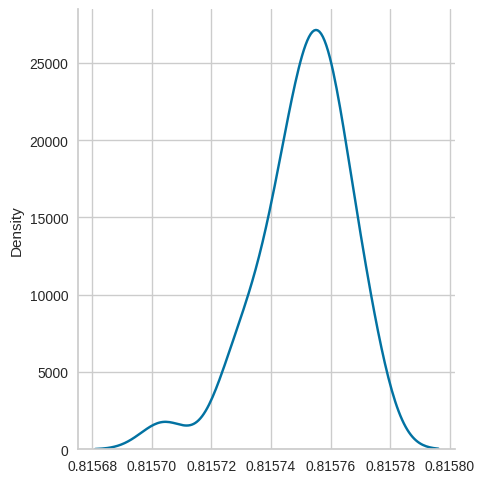

In [385]:
sns.displot(result_polynomial_30, kind = 'kde')

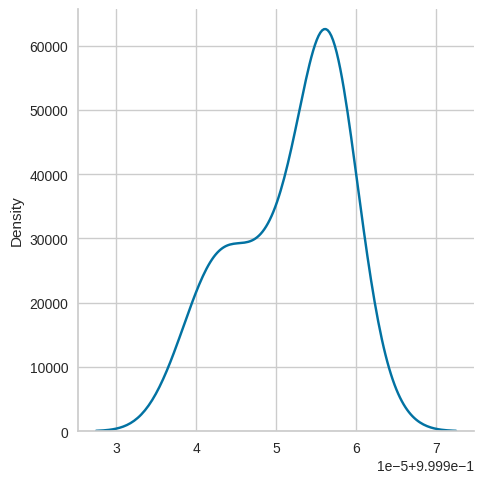

In [386]:
sns.displot(result_decision_tree_30, kind = 'kde')

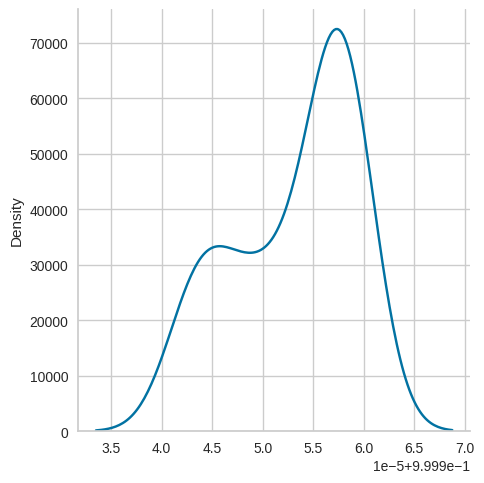

In [387]:
sns.displot(result_random_forest_30, kind = 'kde')

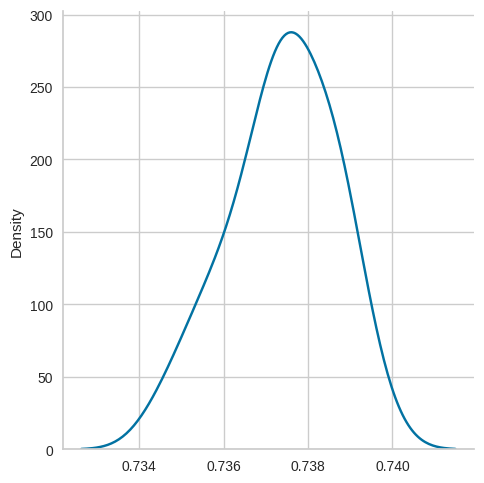

In [388]:
sns.displot(result_neural_network_30, kind = 'kde')

**Hypothesis Testing with ANOVA and Tukey (dados normalizados)**

In [389]:
# se p < alpha (0.05), os dados dos algoritmos são diferentes
_, p = f_oneway(result_polynomial_30, result_decision_tree_30, result_random_forest_30, result_neural_network_30)
p

np.float64(1.529539591641504e-263)

In [390]:
result_algorithm_30 = {'accuracy': np.concatenate([result_polynomial_30, result_decision_tree_30, result_random_forest_30, result_neural_network_30]),
              'algorithm': ['polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial',
               'decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree',
               'random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest',
               'neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network']}

In [391]:
results_test_30_df = pd.DataFrame(result_algorithm_30)
results_test_30_df

,accuracy,algorithm
0,0.815768,polynomial
1,0.815755,polynomial
2,0.815772,polynomial
3,0.815773,polynomial
4,0.815757,polynomial
...,...,...
115,0.735835,neural_network
116,0.739023,neural_network
117,0.737063,neural_network
118,0.737519,neural_network


In [392]:
compare_algorithm_30 = MultiComparison(results_test_30_df['accuracy'], results_test_30_df['algorithm'])

In [393]:
statistical_test_30 = compare_algorithm_30.tukeyhsd()
print(statistical_test_30)

        Multiple Comparison of Means - Tukey HSD, FWER=0.05        
    group1         group2     meandiff p-adj  lower   upper  reject
-------------------------------------------------------------------
 decision_tree neural_network  -0.2626   0.0  -0.263 -0.2621   True
 decision_tree     polynomial  -0.1842   0.0 -0.1846 -0.1838   True
 decision_tree  random_forest      0.0   1.0 -0.0004  0.0004  False
neural_network     polynomial   0.0784   0.0  0.0779  0.0788   True
neural_network  random_forest   0.2626   0.0  0.2621   0.263   True
    polynomial  random_forest   0.1842   0.0  0.1838  0.1846   True
-------------------------------------------------------------------


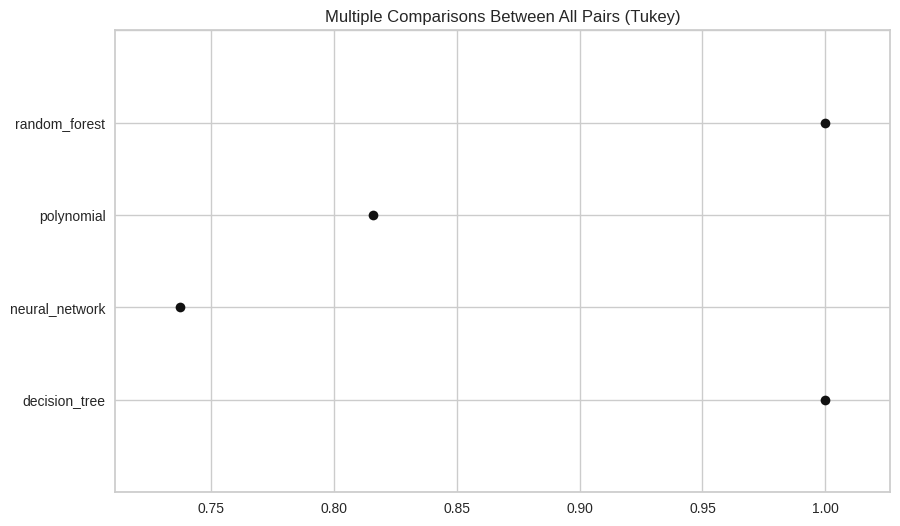

In [394]:
statistical_test_30.plot_simultaneous();

**Hypothesis Testing with Kruskal-Wallis and Nemenyi post-hoc test (dados não normalizados)**

In [395]:
# Conduct the Kruskal-Wallis Test
result_KW_test_30 = stats.kruskal(result_polynomial_30, result_decision_tree_30, result_random_forest_30, result_neural_network_30)
print (result_KW_test_30)

KruskalResult(statistic=np.float64(100.76584022038571), pvalue=np.float64(1.0637022593489887e-21))


/tmp/ipykernel_9929/1005416297.py:2: DeprecationWarning:

Please import `kruskal` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.



In [396]:
# Conduct the Nemenyi post-hoc test
# Combine three groups into one array
!pip install scipy scikit-posthocs numpy
import scikit_posthocs as sp

In [397]:
# Conduct the Nemenyi post-hoc test
# Combine three groups into one array
data_Nemenyi_30 = np.array([result_polynomial_30, result_decision_tree_30, result_random_forest_30,result_neural_network_30])
result_Nemenyi_test_30 = sp.posthoc_nemenyi_friedman(data_Nemenyi_30.T)
print (result_Nemenyi_test_30)

          0             1             2             3
0  1.000000  8.334217e-04  1.191036e-06  1.435777e-02
1  0.000833  1.000000e+00  4.992973e-01  6.276335e-11
2  0.000001  4.992973e-01  1.000000e+00  1.221245e-15
3  0.014358  6.276335e-11  1.221245e-15  1.000000e+00


# **Results Analysis (60)**
Resultados com 60 testes na validação cruzada

In [398]:
#result_decision_tree3 = [0.999943146521737, 0.9999567872776005, 0.9999570673775097, 0.9999447390226738, 0.9999376454084133, 0.999942963582248, 0.9999414348060996, 0.9999569930634793, 0.9999570138284503, 0.9999530645177945, 0.9999638593656359, 0.9999498129770293, 0.9999570823049837, 0.9999568919139575, 0.9999493336871919, 0.9999568136593554, 0.9999569723344848, 0.9999532392503324, 0.999944578356408, 0.9999606251231302, 0.9999501405949642, 0.9999532163257134, 0.9999571614194073, 0.9999416789478579, 0.999941612772157, 0.9999551958116679, 0.9999496247625833, 0.9999566901024277, 0.9999548086058194, 0.9999588800396724, 0.9999567432581535, 0.9999552588619194, 0.999957037945288, 0.9999494450804705, 0.9999400499555271, 0.9999571646851584, 0.9999588468938274, 0.9999569655109679, 0.999957125477113, 0.9999408476837008, 0.9999584746326745, 0.9999531786234825, 0.9999567945582211, 0.9999566716083967, 0.9999572062049455, 0.9999410163909385, 0.9999582597007525, 0.9999568991907546, 0.9999571078776477, 0.9999553372506954, 0.9999568211184998, 0.9999588130321382, 0.999955252354194, 0.9999570077318157, 0.9999568771419935, 0.9999671140709111, 0.9999581596348325, 0.9999546232302775, 0.9999569058645212, 0.9999567929864941, 0.9999557360528787, 0.9999571167234583, 0.9999569505745439, 0.9999429726750684, 0.999958512178788, 0.9999572984674165, 0.9999570642572214, 0.999961330368623, 0.9999571349449123, 0.9999554082280644, 0.9999378185094763, 0.9999500675232376, 0.9999569457381565, 0.9999413850429638, 0.9999552568565612, 0.9999570055446872, 0.9999580692991582, 0.9999583352336417, 0.9999552262146996, 0.9999444287736035, 0.9999478816580336, 0.9999569347527167, 0.9999448375876853, 0.9999599752743655, 0.9999571451325142, 0.999939788728778, 0.9999451890616221, 0.9999571273877024, 0.9999570628953682, 0.999958689591903, 0.999944562318014, 0.9999588894050524, 0.9999569979587098, 0.9999412360612411, 0.999956535869825, 0.9999569289461896, 0.999957095122906, 0.9999420241075754, 0.9999553588622783, 0.9999571040669263, 0.9999547519672074, 0.9999360328402946, 0.9999535847482168, 0.9999567156244981, 0.999957211009581, 0.9999710114397026, 0.9999574472225208, 0.9999569174841492, 0.9999569676132595, 0.9999671431959035, 0.9999553496264337, 0.9999569584436709, 0.9999555636774042, 0.9999583450505911, 0.9999570377716935, 0.9999498153105669, 0.9999519782955121, 0.9999463440773606, 0.9999571288973117, 0.9999569109199575]
result_polynomial_60 = [0.8165713273817718, 0.8165665923950855, 0.8165817936971588, 0.8165786898565286, 0.816621698737488, 0.8165949909316341, 0.816599894556442, 0.816598019822872, 0.816602543484182, 0.8166446683849491, 0.8166176632781763, 0.8165890657342212, 0.8166057532335378, 0.8166118436677071, 0.8165997034202824, 0.81656728445386, 0.8165976760938472, 0.8165475264359136, 0.8166122102911368, 0.8166073777434088, 0.8166013266071788, 0.8165843712539847, 0.816562679449961, 0.8165785093695323, 0.8165967921824315, 0.8166114974365621, 0.816586452159697, 0.8166035233999807, 0.8166026073129771, 0.8165848681297246, 0.8166424272148612, 0.816571220957955, 0.8165267038220391, 0.8165895018697687, 0.8166114881136898, 0.8165847895807646, 0.8165851114662081, 0.8165751782793704, 0.8166180373910211, 0.8166038985496293, 0.8166003489750105, 0.8166013902923235, 0.8166011611414986, 0.8165902253098784, 0.816574191602332, 0.8165911658013982, 0.8166317919515088, 0.8165914927505823, 0.8166096096375234, 0.8165631465081479, 0.8165706345224497, 0.8165770236057069, 0.8166157627122352, 0.816592125031153, 0.8165984921152962, 0.8165904746721517, 0.8165668473323394, 0.8165772932193586, 0.816602318328632, 0.8166388321069145]
#result_polynomial3 =[0.6265713273817718, 0.6265665923950855, 0.6265817936971588, 0.6265786898565286, 0.626621698737488, 0.6265949909316341, 0.626599894556442, 0.626598019822872, 0.626602543484182, 0.6266446683849491, 0.6266176632781763, 0.6265890657342212, 0.6266057532335378, 0.6266118436677071, 0.6265997034202824, 0.62656728445386, 0.6265976760938472, 0.6265475264359136, 0.6266122102911368, 0.6266073777434088, 0.6266013266071788, 0.6265843712539847, 0.626562679449961, 0.6265785093695323, 0.6265967921824315, 0.6266114974365621, 0.626586452159697, 0.6266035233999807, 0.6266026073129771, 0.6265848681297246, 0.6266424272148612, 0.626571220957955, 0.6265267038220391, 0.6265895018697687, 0.6266114881136898, 0.6265847895807646, 0.6265851114662081, 0.6265751782793704, 0.6266180373910211, 0.6266038985496293, 0.6266003489750105, 0.6266013902923235, 0.6266011611414986, 0.6265902253098784, 0.626574191602332, 0.6265911658013982, 0.6266317919515088, 0.6265914927505823, 0.6266096096375234, 0.6265631465081479, 0.6265706345224497, 0.6265770236057069, 0.6266157627122352, 0.626592125031153, 0.6265984921152962, 0.6265904746721517, 0.6265668473323394, 0.6265772932193586, 0.626602318328632, 0.6266388321069145]
result_decision_tree_60 = [0.9999484660048126, 0.9999575010454931, 0.9999567711554782, 0.9999459475921968, 0.9999431776258364, 0.9999454979281228, 0.9999441591309097, 0.9999566106554678, 0.9999589161196557, 0.9999554652614062, 0.9999593506338247, 0.9999533926484968, 0.9999571311661903, 0.9999531501045335, 0.9999444461071224, 0.9999566529019479, 0.9999570212646528, 0.9999505401933486, 0.9999463447276671, 0.9999569905651731, 0.9999528929961607, 0.9999529490836471, 0.9999589221141276, 0.9999440689644524, 0.999944403102964, 0.9999581540888871, 0.9999549734450014, 0.9999563793575847, 0.9999568835985782, 0.9999576338999013, 0.9999564554221614, 0.9999532592462484, 0.999959003338821, 0.9999530092639262, 0.9999457374645555, 0.9999555733191936, 0.9999538292457016, 0.9999550081865743, 0.9999581008680336, 0.9999429560760944, 0.9999544420985235, 0.9999526526028235, 0.9999581332573835, 0.9999566396116097, 0.9999576089187843, 0.9999464595025828, 0.9999561029636995, 0.9999537621963628, 0.9999586271902089, 0.9999590416701383, 0.9999584663013683, 0.999953855811748, 0.9999552017614324, 0.9999587282904144, 0.9999574815173121, 0.9999621830831478, 0.9999577112181928, 0.9999544842460513, 0.9999585364678463, 0.999955832232341]
result_random_forest_60 = [0.9999448391620099, 0.999958514264906, 0.9999570673775097, 0.9999447390226738, 0.9999359393511884, 0.9999446619893331, 0.9999414348060996, 0.9999553021122038, 0.9999570138284503, 0.9999530645177945, 0.999962184416941, 0.9999498129770293, 0.9999570823049837, 0.9999551777703968, 0.9999493336871919, 0.999955095841613, 0.9999552842285337, 0.9999532392503324, 0.999946270243085, 0.9999572388707858, 0.9999484429552385, 0.9999532163257134, 0.9999571614194073, 0.9999416789478579, 0.999941612772157, 0.9999551958116679, 0.9999513167071434, 0.9999583736603336, 0.9999581923852989, 0.999957198031462, 0.9999567432581535, 0.9999569619861182, 0.999957037945288, 0.9999494450804705, 0.9999400499555271, 0.999955457385545, 0.9999571417464814, 0.9999552711318426, 0.999957125477113, 0.9999391487599144, 0.9999567693330587, 0.9999531786234825, 0.9999567945582211, 0.9999583901983813, 0.9999572062049455, 0.9999410163909385, 0.9999582597007525, 0.9999568991907546, 0.9999571078776477, 0.9999553372506954, 0.9999568211184998, 0.9999588130321382, 0.9999569663845259, 0.9999570077318157, 0.9999568771419935, 0.999965424267075, 0.9999581596348325, 0.9999546232302775, 0.9999569058645212, 0.9999567929864941]
result_neural_network_60 = [0.7355617883876759, 0.7386313406242563, 0.7367214372779667, 0.7357803049451711, 0.7382879919537916, 0.7365781398463648, 0.7367255239155929, 0.7370336152303343, 0.7365604132389272, 0.735800300954838, 0.7360559201189976, 0.736265520906961, 0.7387531842423051, 0.736735217896185, 0.7388923555448701, 0.7377627489434608, 0.7376969551124896, 0.7373704212333626, 0.7357588697710584, 0.7375725395632089, 0.738004462501894, 0.736087304299287, 0.7352010377272595, 0.7387107806799057, 0.7379369373362578, 0.7381341363237767, 0.7370678465074582, 0.7345779906110821, 0.7359376051620564, 0.7368517509780408, 0.7356828685558556, 0.7372504075600227, 0.735954912903826, 0.7357766757010071, 0.7365270477706933, 0.7372907491940432, 0.7359776352421746, 0.7372713808969119, 0.7383911549839496, 0.7375136205254523, 0.7371898808660311, 0.7363794295379793, 0.7360060835367299, 0.7379240661872748, 0.7377362967853992, 0.737686684226016, 0.7368081228451133, 0.7373484431844067, 0.7340633263903394, 0.737081753332193, 0.7361777030162584, 0.7362476446227569, 0.735839653029098, 0.7374622778292671, 0.7366017172018027, 0.7378232419316892,  0.7390012362141941, 0.7392012362141941, 0.7394012362141941, 0.73960012362141941]

In [399]:
results_60_df = pd.DataFrame({'Polynomial': result_polynomial_60, 'Decision Tree': result_decision_tree_60, 'Random Forest': result_random_forest_60, "Neural Network": result_neural_network_60})
results_60_df

,Polynomial,Decision Tree,Random Forest,Neural Network
0,0.816571,0.999948,0.999945,0.735562
1,0.816567,0.999958,0.999959,0.738631
2,0.816582,0.999957,0.999957,0.736721
3,0.816579,0.999946,0.999945,0.735780
4,0.816622,0.999943,0.999936,0.738288
5,0.816595,0.999945,0.999945,0.736578
6,0.816600,0.999944,0.999941,0.736726
7,0.816598,0.999957,0.999955,0.737034
8,0.816603,0.999959,0.999957,0.736560
9,0.816645,0.999955,0.999953,0.735800


In [400]:
results_60_df.describe()

,Polynomial,Decision Tree,Random Forest,Neural Network
count,60.000000,60.000000,60.000000,60.000000
mean,0.816594,0.999954,0.999953,0.737038
std,0.000022,0.000005,0.000006,0.001188
min,0.816527,0.999943,0.999936,0.734063
25%,0.816579,0.999953,0.999951,0.736079
50%,0.816596,0.999956,0.999957,0.737051
75%,0.816604,0.999958,0.999957,0.737778
max,0.816645,0.999962,0.999965,0.739600


In [401]:
# Variance
results_60_df.var()

,0
Polynomial,4.763208e-10
Decision Tree,2.499887e-11
Random Forest,3.930091e-11
Neural Network,1.411314e-06


In [402]:
# Coefficient of variation (%)
(results_60_df.std() / results_60_df.mean()) * 100

,0
Polynomial,0.002673
Decision Tree,0.000500
Random Forest,0.000627
Neural Network,0.161184


# **Statistical Tests (60)**

**Test of normality of results**

In [403]:
alpha = 0.05
shapiro (result_polynomial_60), shapiro (result_decision_tree_60), shapiro (result_random_forest_60), shapiro (result_neural_network_60)

(ShapiroResult(statistic=np.float64(0.9800340099378327), pvalue=np.float64(0.4299762194813227)),
 ShapiroResult(statistic=np.float64(0.8589086684716053), pvalue=np.float64(5.636781894631199e-06)),
 ShapiroResult(statistic=np.float64(0.8305837364471894), pvalue=np.float64(8.526906746951769e-07)),
 ShapiroResult(statistic=np.float64(0.9867260211900024), pvalue=np.float64(0.7591215438801651)))

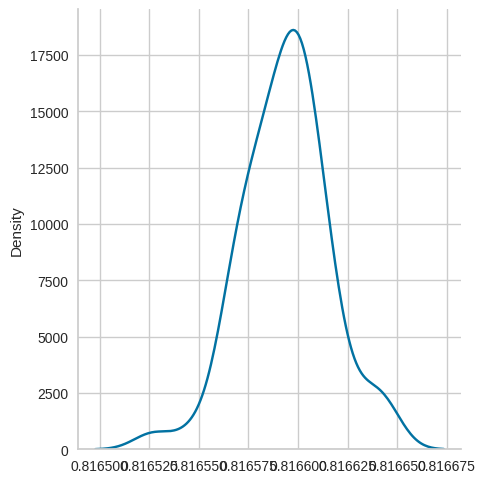

In [404]:
sns.displot(result_polynomial_60, kind = 'kde')

/tmp/ipykernel_9929/3798622946.py:2: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




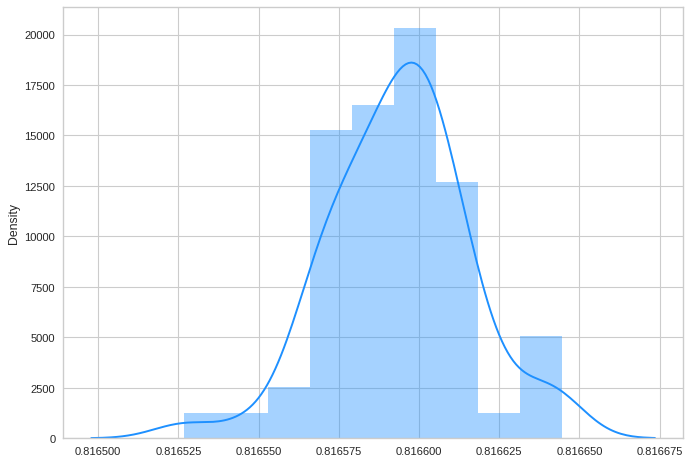

In [405]:
plt.figure(figsize=(10,7), dpi= 80)
sns.distplot(result_polynomial_60, color="dodgerblue", label="Compact",)
plt.show()

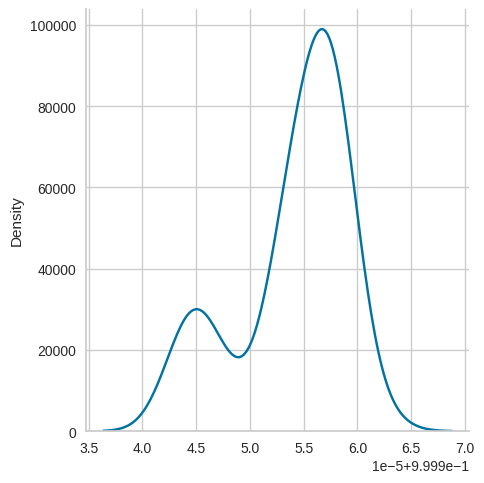

In [406]:
sns.displot(result_decision_tree_60, kind = 'kde')

/tmp/ipykernel_9929/867712040.py:2: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




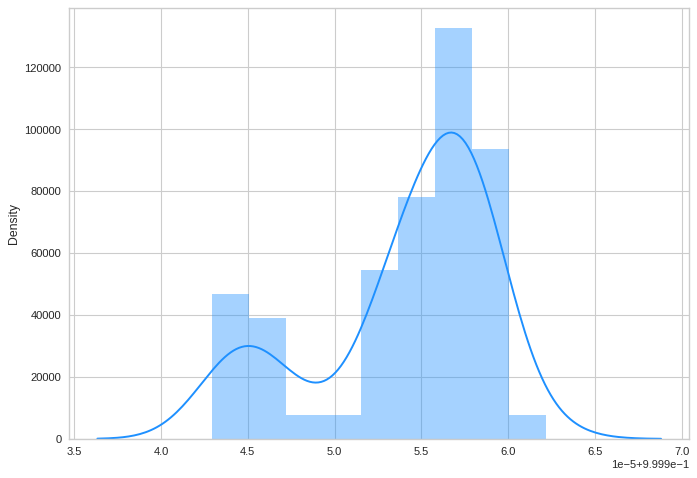

In [407]:
plt.figure(figsize=(10,7), dpi= 80)
sns.distplot(result_decision_tree_60, color="dodgerblue", label="Compact",)
plt.show()

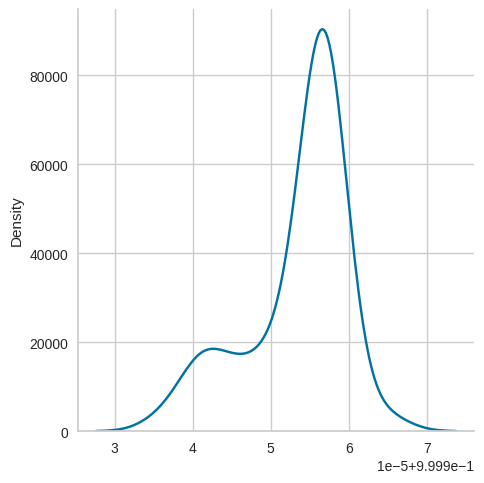

In [408]:
sns.displot(result_random_forest_60, kind = 'kde')

/tmp/ipykernel_9929/23757131.py:2: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




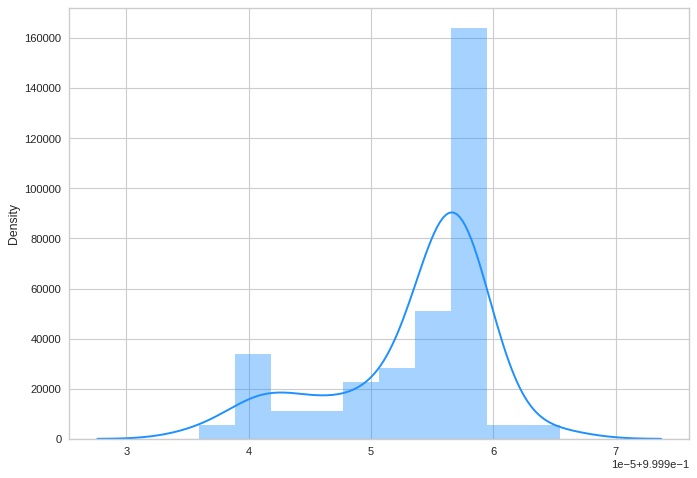

In [409]:
plt.figure(figsize=(10,7), dpi= 80)
sns.distplot(result_random_forest_60, color="dodgerblue", label="Compact",)
plt.show()

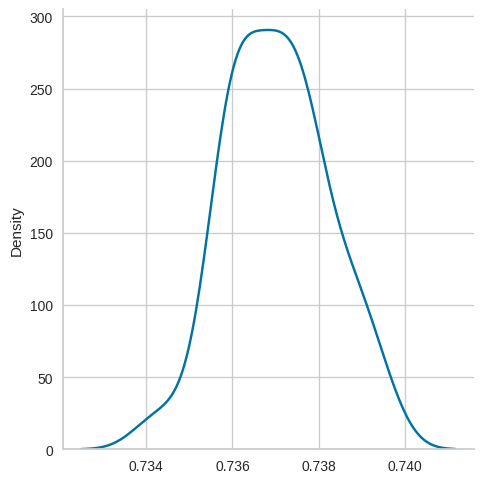

In [410]:
sns.displot(result_neural_network_60, kind = 'kde')

/tmp/ipykernel_9929/2952555192.py:2: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




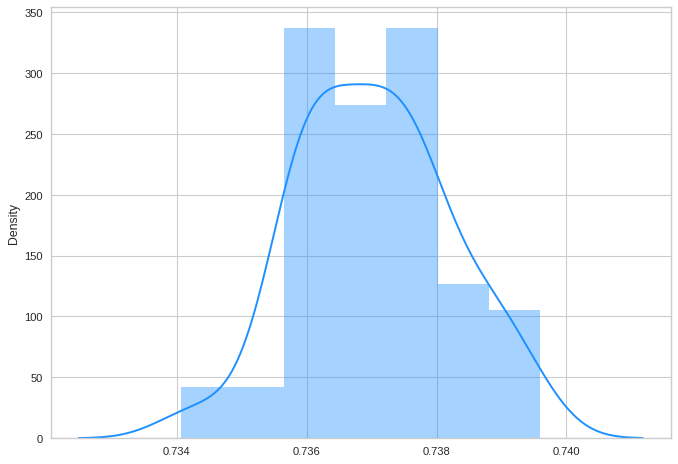

In [411]:
plt.figure(figsize=(10,7), dpi= 80)
sns.distplot(result_neural_network_60, color="dodgerblue", label="Compact",)
plt.show()

**Hypothesis Testing with ANOVA and Tukey (dados normalizados)**

In [412]:
# se p < alpha (0.05), há diferença estatística entre os algoritmos
_, p = f_oneway(result_polynomial_60, result_decision_tree_60,
                result_random_forest_60, result_neural_network_60)
print(p)

0.0


In [413]:
result_algorithm_60 = {'accuracy': np.concatenate([result_polynomial_60, result_decision_tree_60, result_random_forest_60, result_neural_network_60]),
              'algorithm': ['polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial',
               'decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree', 'decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree',
               'random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest',
               'neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network', 'neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network']}

In [414]:
results_test_60_df = pd.DataFrame(result_algorithm_60)
results_test_60_df

,accuracy,algorithm
0,0.816571,polynomial
1,0.816567,polynomial
2,0.816582,polynomial
3,0.816579,polynomial
4,0.816622,polynomial
...,...,...
235,0.737823,neural_network
236,0.739001,neural_network
237,0.739201,neural_network
238,0.739401,neural_network


In [415]:
compare_algorithm_60 = MultiComparison(results_test_60_df['accuracy'], results_test_60_df['algorithm'])

In [416]:
statistical_test_60 = compare_algorithm_60.tukeyhsd()
print(statistical_test_60)

        Multiple Comparison of Means - Tukey HSD, FWER=0.05        
    group1         group2     meandiff p-adj  lower   upper  reject
-------------------------------------------------------------------
 decision_tree neural_network  -0.2629   0.0 -0.2632 -0.2626   True
 decision_tree     polynomial  -0.1834   0.0 -0.1836 -0.1831   True
 decision_tree  random_forest     -0.0   1.0 -0.0003  0.0003  False
neural_network     polynomial   0.0796   0.0  0.0793  0.0798   True
neural_network  random_forest   0.2629   0.0  0.2626  0.2632   True
    polynomial  random_forest   0.1834   0.0  0.1831  0.1836   True
-------------------------------------------------------------------


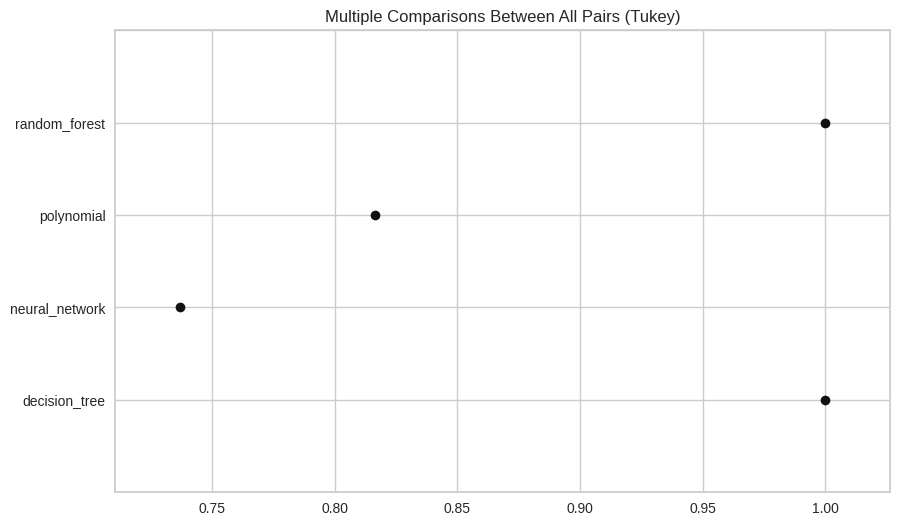

In [417]:
statistical_test_60.plot_simultaneous();

**Hypothesis Testing with Kruskal-Wallis and Nemenyi post-hoc test (dados não normalizados)**

In [418]:
# Conduct the Kruskal-Wallis Test
result_KW_test_60 = stats.kruskal(result_polynomial_60, result_decision_tree_60,
                                  result_random_forest_60, result_neural_network_60)
print (result_KW_test_60)

KruskalResult(statistic=np.float64(201.67313969571228), pvalue=np.float64(1.8349992749716806e-43))


/tmp/ipykernel_9929/2666321250.py:2: DeprecationWarning:

Please import `kruskal` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.



In [419]:
# Conduct the Nemenyi post-hoc test
# Combine three groups into one array
!pip install scipy scikit-posthocs numpy
import scikit_posthocs as sp

In [420]:
# Conduct the Nemenyi post-hoc test
data_Nemenyi_60 = np.array([result_polynomial_60, result_decision_tree_60,
                            result_random_forest_60, result_neural_network_60])
result_Nemenyi_test_60 = sp.posthoc_nemenyi_friedman(data_Nemenyi_60.T)
print (result_Nemenyi_test_60)

              0             1             2        3
0  1.000000e+00  1.108930e-10  1.109491e-08  0.00013
1  1.108930e-10  1.000000e+00  8.943255e-01  0.00000
2  1.109491e-08  8.943255e-01  1.000000e+00  0.00000
3  1.298172e-04  0.000000e+00  0.000000e+00  1.00000
